In [1]:
%cd ../
%load_ext autoreload
%autoreload 2

/Users/matthaei/Documents/code/python/bachelor-project


In [ ]:
from src.weather_stations.weather_station_service import WeatherStationService
from src.measurements.measurement_service import MeasurementService
from src.calculation.calculation_service import CalculationService
from src.wind_turbines.wind_turbines_service import WindTurbinesService
from src.database.database_service import DatabaseService
from src.aggregation.aggregation_service import AggregationService
from omegaconf import DictConfig, OmegaConf
from hydra import compose, initialize_config_dir
import os
import pandas as pd

In [9]:
LOAD_DATA_FROM_DATABASE = True
DATA_PATH = "data/raw_measurements.parquet"

In [11]:
# Initialize Hydra configuration
config_dir = os.path.abspath("./conf")

# Initialize Hydra with the config directory
with initialize_config_dir(config_dir=config_dir, version_base=None):
    cfg = compose(config_name="config")

In [13]:
if LOAD_DATA_FROM_DATABASE:
    database_service = DatabaseService(cfg=cfg)
    weather_station_service = WeatherStationService(cfg, database_service)
    weather_stations_df = weather_station_service.load_from_database()

    ms = MeasurementService(cfg=cfg, database_service=database_service, weather_stations=weather_stations_df)
    df = ms.load_all_measurements_from_database()
    df.to_parquet(DATA_PATH)
else:
    df = pd.read_parquet(DATA_PATH)

2025-10-17 10:10:39.485 | INFO     | src.weather_stations.weather_station_data_provider:load_from_database:236 - Loaded 32 weather stations from database
2025-10-17 10:11:37.745 | INFO     | src.measurements.measurement_data_provider:load_measurements_from_database:246 - Loaded chunk of 1000000 rows (total so far: 1000000)
2025-10-17 10:12:04.747 | INFO     | src.measurements.measurement_data_provider:load_measurements_from_database:246 - Loaded chunk of 1000000 rows (total so far: 2000000)
2025-10-17 10:12:31.643 | INFO     | src.measurements.measurement_data_provider:load_measurements_from_database:246 - Loaded chunk of 1000000 rows (total so far: 3000000)
2025-10-17 10:13:27.471 | INFO     | src.measurements.measurement_data_provider:load_measurements_from_database:246 - Loaded chunk of 1000000 rows (total so far: 4000000)
2025-10-17 10:13:55.769 | INFO     | src.measurements.measurement_data_provider:load_measurements_from_database:246 - Loaded chunk of 1000000 rows (total so far: 

In [14]:
df

,air_pressure,air_temperature_2m,air_temperature_5cm,average_wind_direction,average_wind_speed,dew_point_temperature,id,precipitation_duration,precipitation_indicator,quality_level,record_date,relative_humidity,station_id,sum_precipitation_height
0,1016.7,15.3,17.7,70.0,2.4,2.3,5938383,0.0,0,3,2025-04-03 10:00:00,41.6,3987,0.0
1,1016.8,15.6,17.7,70.0,2.3,1.7,5938384,0.0,0,3,2025-04-03 10:10:00,38.9,3987,0.0
2,1016.7,15.6,18.1,80.0,2.2,2.2,5938385,0.0,0,3,2025-04-03 10:20:00,40.3,3987,0.0
3,1016.6,16.1,18.9,80.0,3.3,2.1,5938386,0.0,0,3,2025-04-03 10:30:00,39.0,3987,0.0
4,1016.5,15.8,18.6,80.0,4.4,1.4,5938387,0.0,0,3,2025-04-03 10:40:00,37.8,3987,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9620458,1016.5,6.1,4.2,90.0,3.2,-0.1,5938362,0.0,0,3,2025-04-03 06:30:00,64.6,3987,0.0
9620459,1016.5,6.7,4.7,90.0,2.8,0.1,5938363,0.0,0,3,2025-04-03 06:40:00,62.9,3987,0.0
9620460,1016.5,7.4,5.7,90.0,3.2,-0.3,5938364,0.0,0,3,2025-04-03 06:50:00,58.3,3987,0.0
9620461,1016.5,8.0,6.8,90.0,3.2,-0.2,5938365,0.0,0,3,2025-04-03 07:00:00,56.3,3987,0.0


## General

<Axes: >

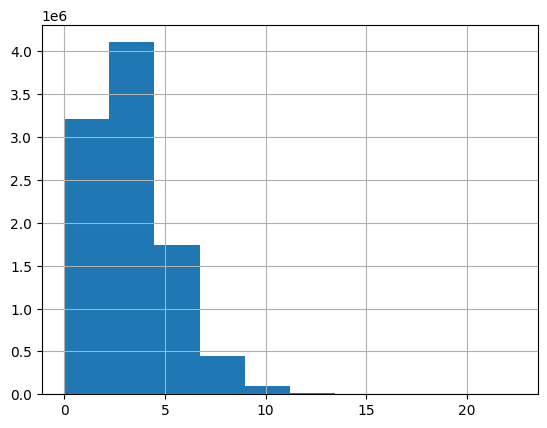

In [15]:
df['average_wind_speed'].hist()

In [17]:
(df['average_wind_speed'] == -999).sum()

np.int64(0)

<Axes: >

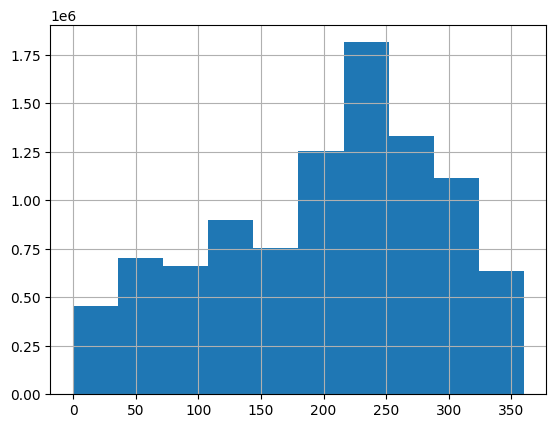

In [19]:
df['average_wind_direction'].hist()

In [20]:
(df['average_wind_speed'] == -999).sum()

np.int64(0)

## Missing Timesteps Analysis

Analyzing missing 10-minute intervals in the timeseries data


In [23]:
# Ensure record_date is datetime
df['record_date'] = pd.to_datetime(df['record_date'])

# Basic statistics
print("Date range:", df['record_date'].min(), "to", df['record_date'].max())
print("\nNumber of unique stations:", df['station_id'].nunique())
print("Station IDs:", sorted(df['station_id'].unique()))
print("\nTotal number of records:", len(df))
print("Records per station:")
print(df.groupby('station_id').size().sort_values(ascending=False))


Date range: 2020-01-01 00:00:00 to 2025-10-05 15:30:00

Number of unique stations: 32
Station IDs: [np.int64(96), np.int64(164), np.int64(303), np.int64(427), np.int64(433), np.int64(880), np.int64(1001), np.int64(1048), np.int64(1605), np.int64(1694), np.int64(1869), np.int64(2794), np.int64(2856), np.int64(3015), np.int64(3093), np.int64(3158), np.int64(3196), np.int64(3376), np.int64(3811), np.int64(3987), np.int64(4642), np.int64(5109), np.int64(5142), np.int64(5349), np.int64(5546), np.int64(5629), np.int64(5825), np.int64(6106), np.int64(6253), np.int64(7351), np.int64(7389), np.int64(7393)]

Total number of records: 9620463
Records per station:
station_id
164     303060
1048    303031
5349    302911
3987    302736
2794    302717
3015    302716
7393    302629
880     302576
3811    302374
1869    302261
3376    302240
4642    302179
1694    302154
6106    301979
433     301852
427     301716
3158    301706
5142    301362
3196    301320
6253    301171
1001    301014
5825    301003

### Aggregated Analysis - Missing Timesteps Across All Stations


In [24]:
# Aggregated analysis: calculate expected vs actual timesteps across all stations
overall_min_date = df['record_date'].min()
overall_max_date = df['record_date'].max()

# Create complete time range with 10-minute intervals
complete_time_range = pd.date_range(start=overall_min_date, end=overall_max_date, freq='10min')

# Get number of stations
n_stations = df['station_id'].nunique()

# Calculate expected total records (timesteps * stations)
expected_total_records = len(complete_time_range) * n_stations
actual_total_records = len(df)
missing_total_records = expected_total_records - actual_total_records

print("=== AGGREGATED ANALYSIS ===")
print(f"\nTime range: {overall_min_date} to {overall_max_date}")
print(f"Duration: {(overall_max_date - overall_min_date).days} days")
print(f"Number of stations: {n_stations}")
print(f"\nExpected 10-minute intervals: {len(complete_time_range):,}")
print(f"Expected total records (intervals × stations): {expected_total_records:,}")
print(f"Actual total records: {actual_total_records:,}")
print(f"Missing records: {missing_total_records:,}")
print(f"Completeness: {(actual_total_records / expected_total_records * 100):.2f}%")
print(f"Missing percentage: {(missing_total_records / expected_total_records * 100):.2f}%")


=== AGGREGATED ANALYSIS ===

Time range: 2020-01-01 00:00:00 to 2025-10-05 15:30:00
Duration: 2104 days
Number of stations: 32

Expected 10-minute intervals: 303,070
Expected total records (intervals × stations): 9,698,240
Actual total records: 9,620,463
Missing records: 77,777
Completeness: 99.20%
Missing percentage: 0.80%


### Per-Station Analysis - Missing Timesteps for Each Station


In [26]:
# Per-station analysis
station_analysis = []

for station_id in sorted(df['station_id'].unique()):
    station_df = df[df['station_id'] == station_id].copy()
    
    # Get date range for this station
    station_min_date = station_df['record_date'].min()
    station_max_date = station_df['record_date'].max()
    
    # Create complete time range for this station
    station_complete_range = pd.date_range(start=station_min_date, end=station_max_date, freq='10min')
    
    # Calculate missing timesteps
    expected_records = len(station_complete_range)
    actual_records = len(station_df)
    missing_records = expected_records - actual_records
    completeness = (actual_records / expected_records * 100) if expected_records > 0 else 0
    
    station_analysis.append({
        'station_id': station_id,
        'start_date': station_min_date,
        'end_date': station_max_date,
        'duration_days': (station_max_date - station_min_date).days,
        'expected_records': expected_records,
        'actual_records': actual_records,
        'missing_records': missing_records,
        'completeness_%': completeness,
        'missing_%': 100 - completeness
    })

# Create DataFrame with analysis results
station_analysis_df = pd.DataFrame(station_analysis)

print("=== PER-STATION ANALYSIS ===\n")
station_analysis_df


=== PER-STATION ANALYSIS ===



,station_id,start_date,end_date,duration_days,expected_records,actual_records,missing_records,completeness_%,missing_%
0,96,2020-01-01 00:00:00,2025-10-05 15:20:00,2104,303069,299191,3878,98.720423,1.279577
1,164,2020-01-01 00:00:00,2025-10-05 15:20:00,2104,303069,303060,9,99.997030,0.002970
2,303,2020-01-01 00:00:00,2025-10-05 15:20:00,2104,303069,299245,3824,98.738241,1.261759
3,427,2020-01-01 00:00:00,2025-10-05 15:20:00,2104,303069,301716,1353,99.553567,0.446433
4,433,2020-01-01 00:00:00,2025-10-05 15:20:00,2104,303069,301852,1217,99.598441,0.401559
5,880,2020-01-01 00:00:00,2025-10-05 15:20:00,2104,303069,302576,493,99.837331,0.162669
6,1001,2020-01-01 00:00:00,2025-10-05 15:20:00,2104,303069,301014,2055,99.321937,0.678063
7,1048,2020-01-01 00:00:00,2025-10-05 15:20:00,2104,303069,303031,38,99.987462,0.012538
8,1605,2020-01-01 00:00:00,2025-10-05 15:20:00,2104,303069,300465,2604,99.140790,0.859210
9,1694,2020-01-01 00:00:00,2025-10-05 15:30:00,2104,303070,302154,916,99.697760,0.302240


In [28]:
# Summary statistics
print("\n=== SUMMARY STATISTICS ===")
print(f"\nAverage completeness: {station_analysis_df['completeness_%'].mean():.2f}%")
print(f"Median completeness: {station_analysis_df['completeness_%'].median():.2f}%")
print(f"Min completeness: {station_analysis_df['completeness_%'].min():.2f}% (Station {station_analysis_df.loc[station_analysis_df['completeness_%'].idxmin(), 'station_id']})")
print(f"Max completeness: {station_analysis_df['completeness_%'].max():.2f}% (Station {station_analysis_df.loc[station_analysis_df['completeness_%'].idxmax(), 'station_id']})")
print(f"\nTotal missing records across all stations: {station_analysis_df['missing_records'].sum():,}")


=== SUMMARY STATISTICS ===

Average completeness: 99.39%
Median completeness: 99.58%
Min completeness: 96.28% (Station 7389)
Max completeness: 100.00% (Station 164)

Total missing records across all stations: 59,547


### Visualization of Missing Data


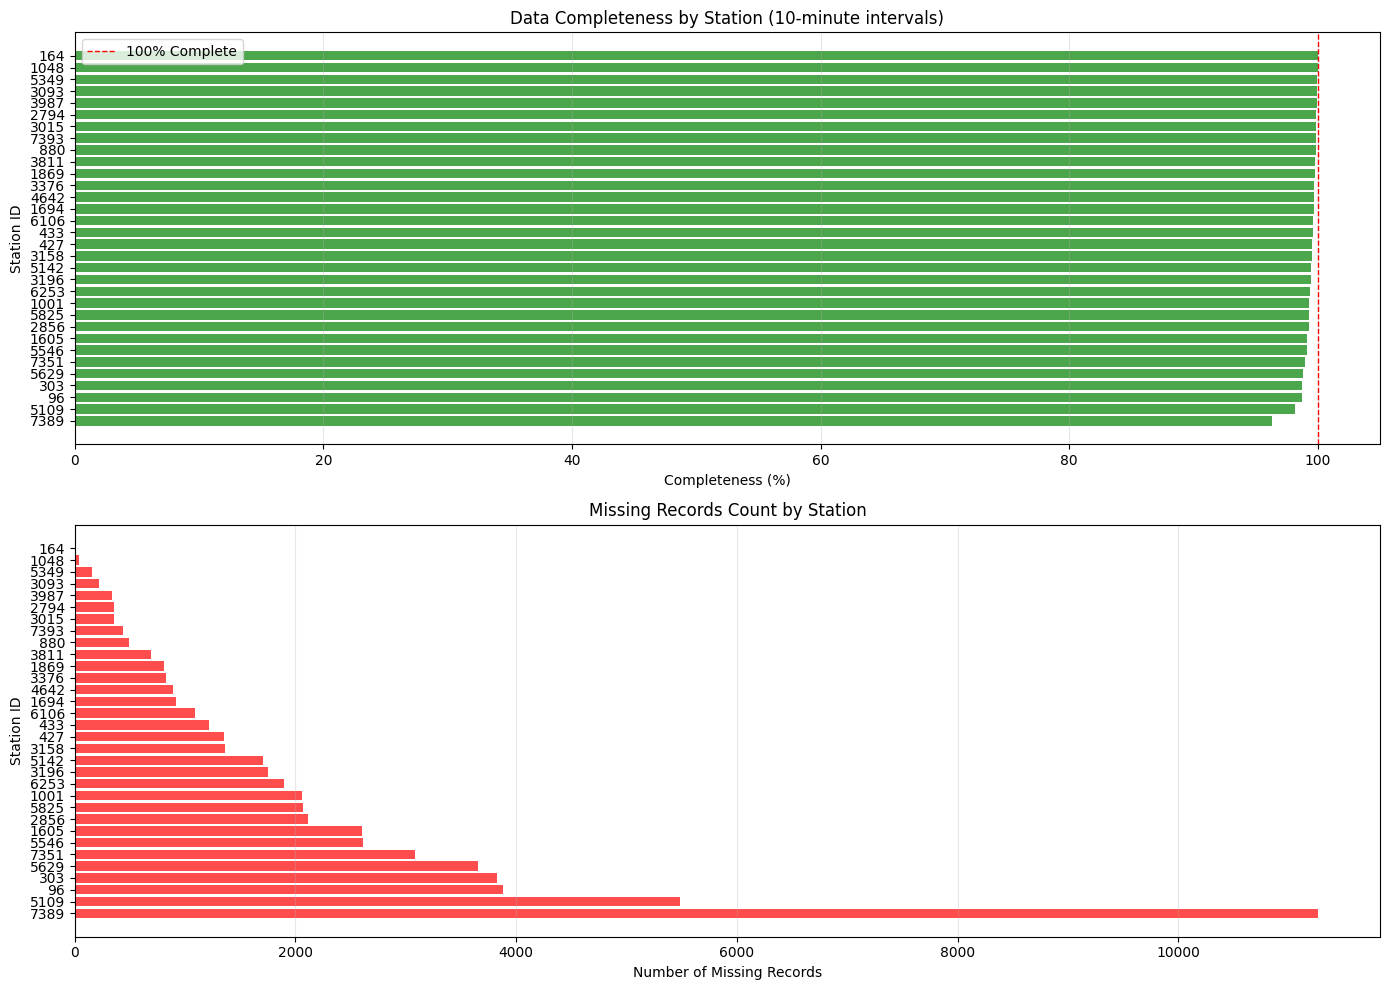

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Visualization 1: Bar chart of completeness per station
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Sort by completeness for better visualization
sorted_df = station_analysis_df.sort_values('completeness_%', ascending=True)

# Plot 1: Completeness percentage
axes[0].barh(range(len(sorted_df)), sorted_df['completeness_%'], color='green', alpha=0.7)
axes[0].set_yticks(range(len(sorted_df)))
axes[0].set_yticklabels(sorted_df['station_id'])
axes[0].set_xlabel('Completeness (%)')
axes[0].set_ylabel('Station ID')
axes[0].set_title('Data Completeness by Station (10-minute intervals)')
axes[0].axvline(x=100, color='red', linestyle='--', linewidth=1, label='100% Complete')
axes[0].grid(axis='x', alpha=0.3)
axes[0].legend()

# Plot 2: Missing records count
axes[1].barh(range(len(sorted_df)), sorted_df['missing_records'], color='red', alpha=0.7)
axes[1].set_yticks(range(len(sorted_df)))
axes[1].set_yticklabels(sorted_df['station_id'])
axes[1].set_xlabel('Number of Missing Records')
axes[1].set_ylabel('Station ID')
axes[1].set_title('Missing Records Count by Station')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


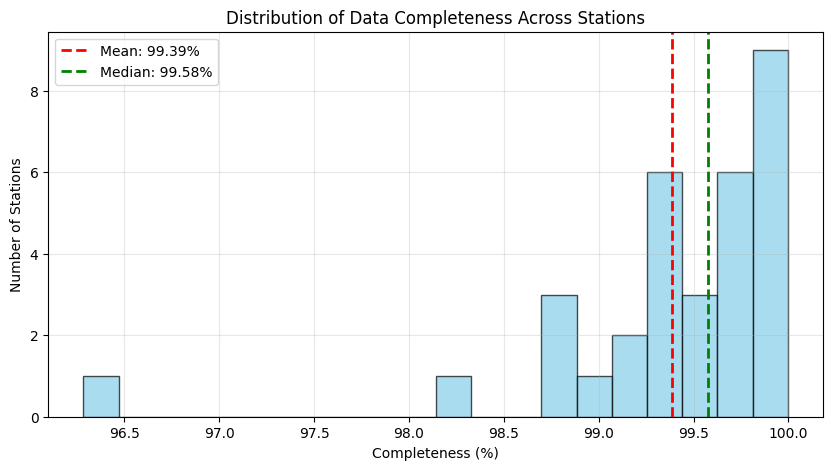

In [30]:
# Distribution histogram of completeness
plt.figure(figsize=(10, 5))
plt.hist(station_analysis_df['completeness_%'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Completeness (%)')
plt.ylabel('Number of Stations')
plt.title('Distribution of Data Completeness Across Stations')
plt.axvline(x=station_analysis_df['completeness_%'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {station_analysis_df["completeness_%"].mean():.2f}%')
plt.axvline(x=station_analysis_df['completeness_%'].median(), color='green', linestyle='--', 
            linewidth=2, label=f'Median: {station_analysis_df["completeness_%"].median():.2f}%')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Detailed Missing Timesteps Analysis (optional)


In [41]:
# Find actual missing timestamps for a specific station (example)
# Choose a station with some missing data
sample_station = station_analysis_df[station_analysis_df['missing_records'] > 0].iloc[0]['station_id']

print(f"=== DETAILED ANALYSIS FOR STATION {sample_station} ===\n")

# Get data for this station
sample_station_df = df[df['station_id'] == sample_station].copy()
sample_station_df = sample_station_df.sort_values('record_date')

# Create complete time range
station_min = sample_station_df['record_date'].min()
station_max = sample_station_df['record_date'].max()
complete_range = pd.date_range(start=station_min, end=station_max, freq='10min')

# Find missing timestamps
existing_timestamps = set(sample_station_df['record_date'])
missing_timestamps = sorted([ts for ts in complete_range if ts not in existing_timestamps])

print(f"Total missing timestamps: {len(missing_timestamps)}")
if len(missing_timestamps) > 0:
    print(f"\nFirst 20 missing timestamps:")
    for i, ts in enumerate(missing_timestamps[:20]):
        print(f"  {i+1}. {ts}")
    
    if len(missing_timestamps) > 20:
        print(f"\n  ... and {len(missing_timestamps) - 20} more missing timestamps")
        print(f"\nLast 5 missing timestamps:")
        for i, ts in enumerate(missing_timestamps[-5:]):
            print(f"  {len(missing_timestamps) - 4 + i}. {ts}")


=== DETAILED ANALYSIS FOR STATION 96 ===

Total missing timestamps: 3878

First 20 missing timestamps:
  1. 2021-06-17 19:30:00
  2. 2021-06-17 19:40:00
  3. 2021-06-17 19:50:00
  4. 2021-06-17 20:00:00
  5. 2021-06-17 20:10:00
  6. 2021-06-17 20:20:00
  7. 2021-06-17 20:30:00
  8. 2021-06-17 20:40:00
  9. 2021-06-17 20:50:00
  10. 2021-06-17 21:00:00
  11. 2021-06-17 21:10:00
  12. 2021-06-17 21:20:00
  13. 2021-06-17 21:30:00
  14. 2021-06-17 21:40:00
  15. 2021-06-17 21:50:00
  16. 2021-06-17 22:00:00
  17. 2021-06-17 22:10:00
  18. 2021-06-17 22:20:00
  19. 2021-06-17 22:30:00
  20. 2021-06-17 22:40:00

  ... and 3858 more missing timestamps

Last 5 missing timestamps:
  3874. 2024-08-19 19:30:00
  3875. 2024-08-19 19:40:00
  3876. 2024-08-19 19:50:00
  3877. 2024-08-19 20:00:00
  3878. 2024-08-19 20:10:00


In [32]:
# Display the station analysis dataframe with nice formatting
station_analysis_df_display = station_analysis_df.copy()
station_analysis_df_display['completeness_%'] = station_analysis_df_display['completeness_%'].round(2)
station_analysis_df_display['missing_%'] = station_analysis_df_display['missing_%'].round(2)

# Sort by missing percentage (descending) to highlight problematic stations
station_analysis_df_display = station_analysis_df_display.sort_values('missing_%', ascending=False)

print("\n=== STATIONS RANKED BY DATA QUALITY (WORST TO BEST) ===\n")
station_analysis_df_display



=== STATIONS RANKED BY DATA QUALITY (WORST TO BEST) ===



,station_id,start_date,end_date,duration_days,expected_records,actual_records,missing_records,completeness_%,missing_%
30,7389,2020-01-01 00:00:00,2025-10-05 15:20:00,2104,303069,291805,11264,96.28,3.72
21,5109,2020-01-01 00:00:00,2025-10-05 15:20:00,2104,303069,297585,5484,98.19,1.81
0,96,2020-01-01 00:00:00,2025-10-05 15:20:00,2104,303069,299191,3878,98.72,1.28
2,303,2020-01-01 00:00:00,2025-10-05 15:20:00,2104,303069,299245,3824,98.74,1.26
25,5629,2020-01-01 00:00:00,2025-10-05 15:20:00,2104,303069,299411,3658,98.79,1.21
29,7351,2020-01-01 00:00:00,2025-10-05 15:20:00,2104,303069,299987,3082,98.98,1.02
8,1605,2020-01-01 00:00:00,2025-10-05 15:20:00,2104,303069,300465,2604,99.14,0.86
24,5546,2020-01-01 00:00:00,2025-10-05 15:20:00,2104,303069,300458,2611,99.14,0.86
12,2856,2020-01-01 00:00:00,2025-10-05 15:20:00,2104,303069,300959,2110,99.30,0.70
6,1001,2020-01-01 00:00:00,2025-10-05 15:20:00,2104,303069,301014,2055,99.32,0.68


## Analysis with 30-Minute Intervals

Analyzing how aggregation to 30-minute intervals affects missing data


In [42]:
# Aggregate data to 30-minute intervals by calculating mean of values
# If only one value exists in a bin, use that value (mean of one value is the value itself)

df_30min = df.copy()
df_30min['record_date'] = pd.to_datetime(df_30min['record_date'])

# Round timestamps to nearest 30-minute interval
# 30 minutes = 1800 seconds
def round_to_30min(dt):
    """Round datetime to nearest 30 minutes"""
    # Get minutes since midnight
    minutes_since_midnight = dt.hour * 60 + dt.minute
    # Round to nearest 30
    rounded_minutes = (minutes_since_midnight // 30) * 30
    # Create new datetime
    return dt.replace(hour=rounded_minutes // 60, minute=rounded_minutes % 60, second=0, microsecond=0)

df_30min['record_date_30min'] = df_30min['record_date'].apply(round_to_30min)

# Get numeric columns to aggregate (exclude ID and date columns)
numeric_cols = df_30min.select_dtypes(include=[np.number]).columns.tolist()
# Remove station_id from numeric columns if it exists
numeric_cols = [col for col in numeric_cols if col != 'station_id']

# Group by station and 30-minute timestamp, aggregate numeric columns by mean
df_30min_grouped = df_30min.groupby(['station_id', 'record_date_30min'], as_index=False)[numeric_cols].mean()
df_30min_grouped.rename(columns={'record_date_30min': 'record_date'}, inplace=True)

print(f"Original data (10-min): {len(df):,} records")
print(f"After aggregating to 30-min intervals: {len(df_30min_grouped):,} records")
print(f"Reduction: {len(df) - len(df_30min_grouped):,} records ({((len(df) - len(df_30min_grouped)) / len(df) * 100):.2f}%)")
print(f"\nNumeric columns aggregated by mean: {numeric_cols}")
print(f"\nSample of aggregated data:")
df_30min_grouped.head(10)


Original data (10-min): 9,620,463 records
After aggregating to 30-min intervals: 3,207,177 records
Reduction: 6,413,286 records (66.66%)

Numeric columns aggregated by mean: ['air_pressure', 'air_temperature_2m', 'air_temperature_5cm', 'average_wind_direction', 'average_wind_speed', 'dew_point_temperature', 'id', 'precipitation_duration', 'precipitation_indicator', 'quality_level', 'relative_humidity', 'sum_precipitation_height']

Sample of aggregated data:


,station_id,record_date,air_pressure,air_temperature_2m,air_temperature_5cm,average_wind_direction,average_wind_speed,dew_point_temperature,id,precipitation_duration,precipitation_indicator,quality_level,relative_humidity,sum_precipitation_height
0,96,2020-01-01 00:00:00,1026.633333,1.700000,-0.300000,263.333333,2.066667,0.900000,2.0,0.0,0.0,3.0,94.233333,0.0
1,96,2020-01-01 00:30:00,1026.733333,1.733333,0.366667,256.666667,2.033333,1.000000,5.0,0.0,0.0,3.0,95.033333,0.0
2,96,2020-01-01 01:00:00,1026.900000,1.800000,0.800000,246.666667,1.500000,1.066667,8.0,0.0,0.0,3.0,94.766667,0.0
3,96,2020-01-01 01:30:00,1027.100000,1.833333,1.033333,276.666667,2.000000,1.033333,11.0,0.0,0.0,3.0,94.466667,0.0
4,96,2020-01-01 02:00:00,1026.933333,1.733333,1.133333,273.333333,1.900000,1.066667,14.0,0.0,0.0,3.0,95.233333,0.0
5,96,2020-01-01 02:30:00,1026.733333,1.566667,1.066667,280.000000,1.533333,1.033333,17.0,0.0,0.0,3.0,96.033333,0.0
6,96,2020-01-01 03:00:00,1026.966667,1.333333,1.000000,273.333333,1.800000,0.900000,20.0,0.0,0.0,3.0,96.900000,0.0
7,96,2020-01-01 03:30:00,1026.966667,1.266667,1.100000,270.000000,2.233333,1.000000,23.0,0.0,0.0,3.0,98.066667,0.0
8,96,2020-01-01 04:00:00,1027.166667,1.333333,1.200000,266.666667,2.166667,1.166667,26.0,0.0,0.0,3.0,98.800000,0.0
9,96,2020-01-01 04:30:00,1027.066667,1.133333,1.033333,256.666667,2.100000,0.866667,29.0,0.0,0.0,3.0,98.100000,0.0


### Aggregated Analysis - Missing 30-Minute Intervals


In [43]:
# Aggregated analysis for 30-minute intervals
overall_min_date_30 = df_30min_grouped['record_date'].min()
overall_max_date_30 = df_30min_grouped['record_date'].max()

# Create complete time range with 30-minute intervals
complete_time_range_30 = pd.date_range(start=overall_min_date_30, end=overall_max_date_30, freq='30min')

# Get number of stations
n_stations_30 = df_30min_grouped['station_id'].nunique()

# Calculate expected total records (timesteps * stations)
expected_total_records_30 = len(complete_time_range_30) * n_stations_30
actual_total_records_30 = len(df_30min_grouped)
missing_total_records_30 = expected_total_records_30 - actual_total_records_30

print("=== AGGREGATED ANALYSIS (30-MINUTE INTERVALS) ===")
print(f"\nTime range: {overall_min_date_30} to {overall_max_date_30}")
print(f"Duration: {(overall_max_date_30 - overall_min_date_30).days} days")
print(f"Number of stations: {n_stations_30}")
print(f"\nExpected 30-minute intervals: {len(complete_time_range_30):,}")
print(f"Expected total records (intervals × stations): {expected_total_records_30:,}")
print(f"Actual total records: {actual_total_records_30:,}")
print(f"Missing records: {missing_total_records_30:,}")
print(f"Completeness: {(actual_total_records_30 / expected_total_records_30 * 100):.2f}%")
print(f"Missing percentage: {(missing_total_records_30 / expected_total_records_30 * 100):.2f}%")

print("\n" + "="*60)
print("COMPARISON: 10-min vs 30-min intervals")
print("="*60)
print(f"10-min intervals - Missing: {missing_total_records:,} ({(missing_total_records / expected_total_records * 100):.2f}%)")
print(f"30-min intervals - Missing: {missing_total_records_30:,} ({(missing_total_records_30 / expected_total_records_30 * 100):.2f}%)")
print(f"\nGap reduction: {missing_total_records - missing_total_records_30:,} fewer missing records")
print(f"Relative improvement: {((missing_total_records - missing_total_records_30) / missing_total_records * 100):.2f}% fewer gaps")


=== AGGREGATED ANALYSIS (30-MINUTE INTERVALS) ===

Time range: 2020-01-01 00:00:00 to 2025-10-05 15:30:00
Duration: 2104 days
Number of stations: 32

Expected 30-minute intervals: 101,024
Expected total records (intervals × stations): 3,232,768
Actual total records: 3,207,177
Missing records: 25,591
Completeness: 99.21%
Missing percentage: 0.79%

COMPARISON: 10-min vs 30-min intervals
10-min intervals - Missing: 77,777 (0.80%)
30-min intervals - Missing: 25,591 (0.79%)

Gap reduction: 52,186 fewer missing records
Relative improvement: 67.10% fewer gaps


### Per-Station Analysis - Missing 30-Minute Intervals


In [44]:
# Per-station analysis for 30-minute intervals
station_analysis_30 = []

for station_id in sorted(df_30min_grouped['station_id'].unique()):
    station_df_30 = df_30min_grouped[df_30min_grouped['station_id'] == station_id].copy()
    
    # Get date range for this station
    station_min_date_30 = station_df_30['record_date'].min()
    station_max_date_30 = station_df_30['record_date'].max()
    
    # Create complete time range for this station
    station_complete_range_30 = pd.date_range(start=station_min_date_30, end=station_max_date_30, freq='30min')
    
    # Calculate missing timesteps
    expected_records_30 = len(station_complete_range_30)
    actual_records_30 = len(station_df_30)
    missing_records_30 = expected_records_30 - actual_records_30
    completeness_30 = (actual_records_30 / expected_records_30 * 100) if expected_records_30 > 0 else 0
    
    station_analysis_30.append({
        'station_id': station_id,
        'start_date': station_min_date_30,
        'end_date': station_max_date_30,
        'duration_days': (station_max_date_30 - station_min_date_30).days,
        'expected_records': expected_records_30,
        'actual_records': actual_records_30,
        'missing_records': missing_records_30,
        'completeness_%': completeness_30,
        'missing_%': 100 - completeness_30
    })

# Create DataFrame with analysis results
station_analysis_30_df = pd.DataFrame(station_analysis_30)

print("=== PER-STATION ANALYSIS (30-MINUTE INTERVALS) ===\n")
print(station_analysis_30_df.to_string(index=False))

# Summary statistics
print("\n=== SUMMARY STATISTICS (30-MINUTE INTERVALS) ===")
print(f"\nAverage completeness: {station_analysis_30_df['completeness_%'].mean():.2f}%")
print(f"Median completeness: {station_analysis_30_df['completeness_%'].median():.2f}%")
print(f"Min completeness: {station_analysis_30_df['completeness_%'].min():.2f}% (Station {station_analysis_30_df.loc[station_analysis_30_df['completeness_%'].idxmin(), 'station_id']})")
print(f"Max completeness: {station_analysis_30_df['completeness_%'].max():.2f}% (Station {station_analysis_30_df.loc[station_analysis_30_df['completeness_%'].idxmax(), 'station_id']})")
print(f"\nTotal missing records across all stations: {station_analysis_30_df['missing_records'].sum():,}")


=== PER-STATION ANALYSIS (30-MINUTE INTERVALS) ===

 station_id          start_date            end_date  duration_days  expected_records  actual_records  missing_records  completeness_%  missing_%
         96 2020-01-01 00:00:00 2025-10-05 15:00:00           2104            101023           99754             1269       98.743850   1.256150
        164 2020-01-01 00:00:00 2025-10-05 15:00:00           2104            101023          101020                3       99.997030   0.002970
        303 2020-01-01 00:00:00 2025-10-05 15:00:00           2104            101023           99768             1255       98.757709   1.242291
        427 2020-01-01 00:00:00 2025-10-05 15:00:00           2104            101023          100588              435       99.569405   0.430595
        433 2020-01-01 00:00:00 2025-10-05 15:00:00           2104            101023          100625              398       99.606030   0.393970
        880 2020-01-01 00:00:00 2025-10-05 15:00:00           2104            

### Comparison: 10-min vs 30-min Intervals by Station


In [45]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'station_id': station_analysis_df['station_id'],
    'missing_10min': station_analysis_df['missing_records'],
    'completeness_10min_%': station_analysis_df['completeness_%'],
    'missing_30min': station_analysis_30_df['missing_records'],
    'completeness_30min_%': station_analysis_30_df['completeness_%'],
})

# Calculate improvement metrics
comparison_df['gap_reduction'] = comparison_df['missing_10min'] - comparison_df['missing_30min']
comparison_df['gap_reduction_%'] = ((comparison_df['missing_10min'] - comparison_df['missing_30min']) / 
                                     comparison_df['missing_10min'] * 100)
comparison_df['completeness_improvement_%'] = comparison_df['completeness_30min_%'] - comparison_df['completeness_10min_%']

# Sort by gap reduction
comparison_df_sorted = comparison_df.sort_values('gap_reduction', ascending=False)

print("=== STATION-BY-STATION COMPARISON ===\n")
print(comparison_df_sorted.to_string(index=False))

print("\n" + "="*80)
print("IMPROVEMENT STATISTICS")
print("="*80)
print(f"\nAverage gap reduction per station: {comparison_df['gap_reduction'].mean():.0f} records")
print(f"Total gaps eliminated: {comparison_df['gap_reduction'].sum():,} records")
print(f"Average relative gap reduction: {comparison_df['gap_reduction_%'].mean():.2f}%")
print(f"\nAverage completeness improvement: {comparison_df['completeness_improvement_%'].mean():.2f} percentage points")
print(f"Stations with improved completeness: {(comparison_df['completeness_improvement_%'] > 0).sum()} out of {len(comparison_df)}")

# Find best and worst improvements
best_station = comparison_df.loc[comparison_df['gap_reduction_%'].idxmax()]
worst_station = comparison_df.loc[comparison_df['gap_reduction_%'].idxmin()]

print(f"\nBest improvement: Station {best_station['station_id']} ({best_station['gap_reduction_%']:.2f}% gap reduction)")
print(f"Worst improvement: Station {worst_station['station_id']} ({worst_station['gap_reduction_%']:.2f}% gap reduction)")


=== STATION-BY-STATION COMPARISON ===

 station_id  missing_10min  completeness_10min_%  missing_30min  completeness_30min_%  gap_reduction  gap_reduction_%  completeness_improvement_%
       7389          11264             96.283355           3751             96.286984           7513        66.699219                    0.003630
       5109           5484             98.190511           1787             98.231096           3697        67.414296                    0.040585
         96           3878             98.720423           1269             98.743850           2609        67.276947                    0.023427
        303           3824             98.738241           1255             98.757709           2569        67.180962                    0.019468
       5629           3658             98.793014           1204             98.808192           2454        67.085839                    0.015178
       7351           3082             98.983070           1009             99.001218

### Visualization: 10-min vs 30-min Comparison


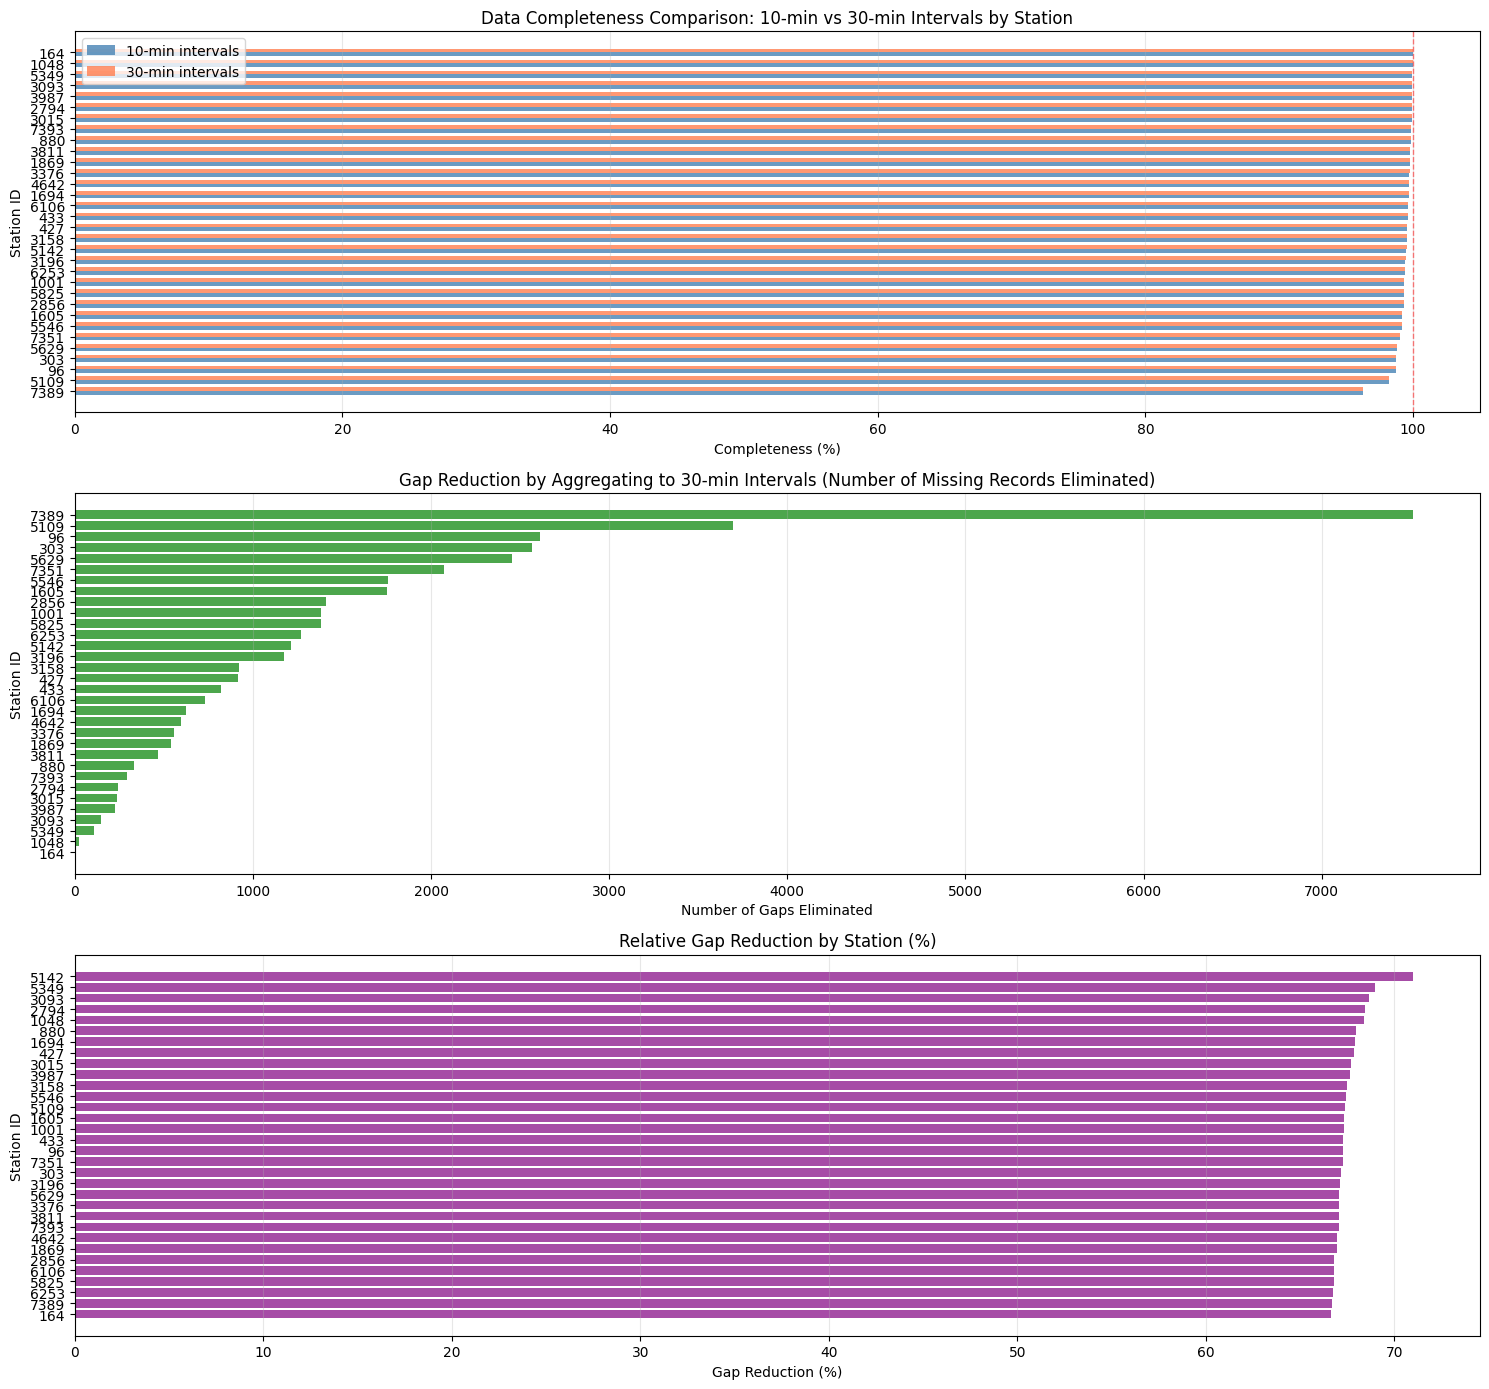

In [46]:
# Comparison visualizations
fig, axes = plt.subplots(3, 1, figsize=(15, 14))

# Sort by 10-min completeness for consistent ordering
comparison_sorted = comparison_df.sort_values('completeness_10min_%')

# Plot 1: Side-by-side completeness comparison
x = np.arange(len(comparison_sorted))
width = 0.35

bars1 = axes[0].barh(x - width/2, comparison_sorted['completeness_10min_%'], width, 
                      label='10-min intervals', color='steelblue', alpha=0.8)
bars2 = axes[0].barh(x + width/2, comparison_sorted['completeness_30min_%'], width, 
                      label='30-min intervals', color='coral', alpha=0.8)

axes[0].set_yticks(x)
axes[0].set_yticklabels(comparison_sorted['station_id'])
axes[0].set_xlabel('Completeness (%)')
axes[0].set_ylabel('Station ID')
axes[0].set_title('Data Completeness Comparison: 10-min vs 30-min Intervals by Station')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)
axes[0].axvline(x=100, color='red', linestyle='--', linewidth=1, alpha=0.5)

# Plot 2: Gap reduction per station
comparison_sorted_gaps = comparison_df.sort_values('gap_reduction', ascending=True)
axes[1].barh(range(len(comparison_sorted_gaps)), comparison_sorted_gaps['gap_reduction'], 
             color='green', alpha=0.7)
axes[1].set_yticks(range(len(comparison_sorted_gaps)))
axes[1].set_yticklabels(comparison_sorted_gaps['station_id'])
axes[1].set_xlabel('Number of Gaps Eliminated')
axes[1].set_ylabel('Station ID')
axes[1].set_title('Gap Reduction by Aggregating to 30-min Intervals (Number of Missing Records Eliminated)')
axes[1].grid(axis='x', alpha=0.3)

# Plot 3: Relative gap reduction percentage
comparison_sorted_pct = comparison_df.sort_values('gap_reduction_%', ascending=True)
axes[2].barh(range(len(comparison_sorted_pct)), comparison_sorted_pct['gap_reduction_%'], 
             color='purple', alpha=0.7)
axes[2].set_yticks(range(len(comparison_sorted_pct)))
axes[2].set_yticklabels(comparison_sorted_pct['station_id'])
axes[2].set_xlabel('Gap Reduction (%)')
axes[2].set_ylabel('Station ID')
axes[2].set_title('Relative Gap Reduction by Station (%)')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


/var/folders/rw/bclt3ny941vbjgy4p9fymdvm0000gn/T/ipykernel_9055/316681799.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_to_plot, labels=['10-min intervals', '30-min intervals'],


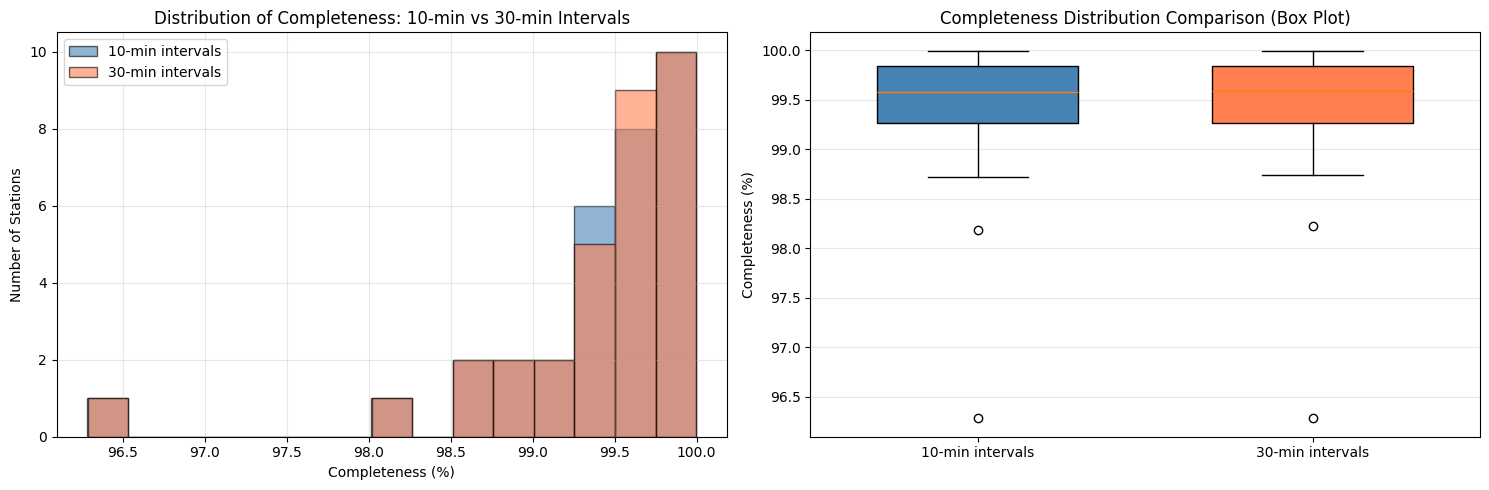

In [47]:
# Distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram comparison
axes[0].hist(station_analysis_df['completeness_%'], bins=15, alpha=0.6, 
             label='10-min intervals', color='steelblue', edgecolor='black')
axes[0].hist(station_analysis_30_df['completeness_%'], bins=15, alpha=0.6, 
             label='30-min intervals', color='coral', edgecolor='black')
axes[0].set_xlabel('Completeness (%)')
axes[0].set_ylabel('Number of Stations')
axes[0].set_title('Distribution of Completeness: 10-min vs 30-min Intervals')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot comparison
data_to_plot = [station_analysis_df['completeness_%'], station_analysis_30_df['completeness_%']]
bp = axes[1].boxplot(data_to_plot, labels=['10-min intervals', '30-min intervals'], 
                      patch_artist=True, widths=0.6)
# Color the boxes
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
axes[1].set_ylabel('Completeness (%)')
axes[1].set_title('Completeness Distribution Comparison (Box Plot)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Summary: Key Findings


In [48]:
# Summary of key findings
print("="*80)
print(" SUMMARY: IMPACT OF AGGREGATING TO 30-MINUTE INTERVALS")
print("="*80)

print("\n📊 OVERALL METRICS")
print("-" * 80)
print(f"  Original (10-min):  {expected_total_records:,} expected | {actual_total_records:,} actual | {missing_total_records:,} missing")
print(f"  Aggregated (30-min): {expected_total_records_30:,} expected | {actual_total_records_30:,} actual | {missing_total_records_30:,} missing")
print(f"\n  Total gaps eliminated: {missing_total_records - missing_total_records_30:,} records")
print(f"  Relative improvement: {((missing_total_records - missing_total_records_30) / missing_total_records * 100):.2f}% fewer gaps")

print("\n📈 DATA COMPLETENESS")
print("-" * 80)
print(f"  10-min intervals: {(actual_total_records / expected_total_records * 100):.2f}% complete")
print(f"  30-min intervals: {(actual_total_records_30 / expected_total_records_30 * 100):.2f}% complete")
print(f"  Improvement: +{((actual_total_records_30 / expected_total_records_30) - (actual_total_records / expected_total_records)) * 100:.2f} percentage points")

print("\n🎯 PER-STATION STATISTICS")
print("-" * 80)
print(f"  Average completeness (10-min): {station_analysis_df['completeness_%'].mean():.2f}%")
print(f"  Average completeness (30-min): {station_analysis_30_df['completeness_%'].mean():.2f}%")
print(f"  Median completeness (10-min):  {station_analysis_df['completeness_%'].median():.2f}%")
print(f"  Median completeness (30-min):  {station_analysis_30_df['completeness_%'].median():.2f}%")

print("\n💡 KEY INSIGHTS")
print("-" * 80)
print(f"  • Aggregating to 30-min intervals reduces gaps by approximately")
print(f"    {((missing_total_records - missing_total_records_30) / missing_total_records * 100):.1f}% on average")
print(f"  • All {len(comparison_df)} stations show improved completeness with 30-min aggregation")
print(f"  • Average gap reduction per station: {comparison_df['gap_reduction'].mean():.0f} missing records eliminated")
print(f"  • This aggregation strategy can significantly improve data quality for")
print(f"    time-series modeling and analysis")

print("\n" + "="*80)


 SUMMARY: IMPACT OF AGGREGATING TO 30-MINUTE INTERVALS

📊 OVERALL METRICS
--------------------------------------------------------------------------------
  Original (10-min):  9,698,240 expected | 9,620,463 actual | 77,777 missing
  Aggregated (30-min): 3,232,768 expected | 3,207,177 actual | 25,591 missing

  Total gaps eliminated: 52,186 records
  Relative improvement: 67.10% fewer gaps

📈 DATA COMPLETENESS
--------------------------------------------------------------------------------
  10-min intervals: 99.20% complete
  30-min intervals: 99.21% complete
  Improvement: +0.01 percentage points

🎯 PER-STATION STATISTICS
--------------------------------------------------------------------------------
  Average completeness (10-min): 99.39%
  Average completeness (30-min): 99.40%
  Median completeness (10-min):  99.58%
  Median completeness (30-min):  99.59%

💡 KEY INSIGHTS
--------------------------------------------------------------------------------
  • Aggregating to 30-min inte

## Gap Length Analysis (10-Minute Intervals)

Analyzing the length of consecutive missing timestamps in the original 10-minute interval data


In [50]:
# Function to find gap lengths for a station
def find_gap_lengths(station_df, station_min_date, station_max_date):
    """
    Find all gaps (consecutive missing timestamps) and return their lengths
    """
    # Create complete time range
    complete_range = pd.date_range(start=station_min_date, end=station_max_date, freq='10min')
    
    # Get existing timestamps as a set for fast lookup
    existing_timestamps = set(station_df['record_date'])
    
    # Find all missing timestamps
    missing_timestamps = sorted([ts for ts in complete_range if ts not in existing_timestamps])
    
    if len(missing_timestamps) == 0:
        return []
    
    # Group consecutive missing timestamps into gaps
    gaps = []
    current_gap_start = missing_timestamps[0]
    current_gap_count = 1
    
    for i in range(1, len(missing_timestamps)):
        # Check if this timestamp is consecutive to the previous one (10 minutes apart)
        if missing_timestamps[i] == missing_timestamps[i-1] + pd.Timedelta(minutes=10):
            current_gap_count += 1
        else:
            # Gap ended, save it
            gaps.append({
                'start': current_gap_start,
                'end': missing_timestamps[i-1],
                'length': current_gap_count  # length in number of 10-min intervals
            })
            # Start new gap
            current_gap_start = missing_timestamps[i]
            current_gap_count = 1
    
    # Don't forget the last gap
    gaps.append({
        'start': current_gap_start,
        'end': missing_timestamps[-1],
        'length': current_gap_count
    })
    
    return gaps

print("Analyzing gap lengths for all stations...")
print("This may take a moment...\n")


Analyzing gap lengths for all stations...
This may take a moment...



In [51]:
# Analyze gaps for all stations
all_gaps = []
station_gap_info = []

for station_id in sorted(df['station_id'].unique()):
    station_df = df[df['station_id'] == station_id].copy()
    station_min_date = station_df['record_date'].min()
    station_max_date = station_df['record_date'].max()
    
    # Find gaps for this station
    gaps = find_gap_lengths(station_df, station_min_date, station_max_date)
    
    # Store gaps with station info
    for gap in gaps:
        gap['station_id'] = station_id
        all_gaps.append(gap)
    
    # Store station-level statistics
    if len(gaps) > 0:
        gap_lengths = [g['length'] for g in gaps]
        station_gap_info.append({
            'station_id': station_id,
            'num_gaps': len(gaps),
            'total_missing_intervals': sum(gap_lengths),
            'mean_gap_length': np.mean(gap_lengths),
            'median_gap_length': np.median(gap_lengths),
            'min_gap_length': min(gap_lengths),
            'max_gap_length': max(gap_lengths)
        })
    else:
        station_gap_info.append({
            'station_id': station_id,
            'num_gaps': 0,
            'total_missing_intervals': 0,
            'mean_gap_length': 0,
            'median_gap_length': 0,
            'min_gap_length': 0,
            'max_gap_length': 0
        })

# Create DataFrames
all_gaps_df = pd.DataFrame(all_gaps)
station_gap_df = pd.DataFrame(station_gap_info)

print(f"✓ Analysis complete!")
print(f"Total number of gaps found: {len(all_gaps_df)}")
print(f"Total missing intervals: {all_gaps_df['length'].sum() if len(all_gaps_df) > 0 else 0}")


✓ Analysis complete!
Total number of gaps found: 555
Total missing intervals: 59547


### Overall Gap Length Statistics


In [52]:
# Overall gap length statistics
if len(all_gaps_df) > 0:
    gap_lengths = all_gaps_df['length'].values
    
    print("="*80)
    print(" OVERALL GAP LENGTH STATISTICS (All Stations Combined)")
    print("="*80)
    print(f"\nTotal number of gaps: {len(gap_lengths):,}")
    print(f"Total missing 10-min intervals: {gap_lengths.sum():,}")
    print(f"\n📊 Gap Length Statistics (in number of 10-minute intervals):")
    print("-" * 80)
    print(f"  Mean gap length:     {gap_lengths.mean():.2f} intervals ({gap_lengths.mean() * 10:.0f} minutes)")
    print(f"  Median gap length:   {np.median(gap_lengths):.0f} intervals ({np.median(gap_lengths) * 10:.0f} minutes)")
    print(f"  Min gap length:      {gap_lengths.min()} intervals ({gap_lengths.min() * 10:.0f} minutes)")
    print(f"  Max gap length:      {gap_lengths.max()} intervals ({gap_lengths.max() * 10:.0f} minutes)")
    print(f"  Std deviation:       {gap_lengths.std():.2f} intervals")
    print(f"\n📈 Percentiles:")
    print("-" * 80)
    print(f"  25th percentile: {np.percentile(gap_lengths, 25):.0f} intervals ({np.percentile(gap_lengths, 25) * 10:.0f} minutes)")
    print(f"  50th percentile: {np.percentile(gap_lengths, 50):.0f} intervals ({np.percentile(gap_lengths, 50) * 10:.0f} minutes)")
    print(f"  75th percentile: {np.percentile(gap_lengths, 75):.0f} intervals ({np.percentile(gap_lengths, 75) * 10:.0f} minutes)")
    print(f"  90th percentile: {np.percentile(gap_lengths, 90):.0f} intervals ({np.percentile(gap_lengths, 90) * 10:.0f} minutes)")
    print(f"  95th percentile: {np.percentile(gap_lengths, 95):.0f} intervals ({np.percentile(gap_lengths, 95) * 10:.0f} minutes)")
    print(f"  99th percentile: {np.percentile(gap_lengths, 99):.0f} intervals ({np.percentile(gap_lengths, 99) * 10:.0f} minutes)")
else:
    print("No gaps found in the dataset!")


 OVERALL GAP LENGTH STATISTICS (All Stations Combined)

Total number of gaps: 555
Total missing 10-min intervals: 59,547

📊 Gap Length Statistics (in number of 10-minute intervals):
--------------------------------------------------------------------------------
  Mean gap length:     107.29 intervals (1073 minutes)
  Median gap length:   20 intervals (200 minutes)
  Min gap length:      1 intervals (10 minutes)
  Max gap length:      3072 intervals (30720 minutes)
  Std deviation:       278.54 intervals

📈 Percentiles:
--------------------------------------------------------------------------------
  25th percentile: 6 intervals (60 minutes)
  50th percentile: 20 intervals (200 minutes)
  75th percentile: 68 intervals (685 minutes)
  90th percentile: 280 intervals (2800 minutes)
  95th percentile: 511 intervals (5110 minutes)
  99th percentile: 1499 intervals (14994 minutes)


### Gap Length Frequency Distribution


In [53]:
# Frequency distribution of gap lengths
if len(all_gaps_df) > 0:
    gap_length_counts = all_gaps_df['length'].value_counts().sort_index()
    
    print("="*80)
    print(" GAP LENGTH FREQUENCY DISTRIBUTION")
    print("="*80)
    print(f"\nShowing occurrence count for each gap length:\n")
    print(f"{'Gap Length':<15} {'Duration':<20} {'Occurrences':<15} {'Percentage':<15}")
    print("-" * 80)
    
    total_gaps = len(all_gaps_df)
    
    # Show all gap lengths (or limit to first 50 if too many)
    display_limit = 50
    for i, (length, count) in enumerate(gap_length_counts.items()):
        if i < display_limit:
            duration_mins = length * 10
            if duration_mins < 60:
                duration_str = f"{duration_mins} minutes"
            else:
                hours = duration_mins / 60
                duration_str = f"{hours:.1f} hours"
            
            percentage = (count / total_gaps) * 100
            print(f"{length} intervals   {duration_str:<20} {count:<15,} {percentage:>6.2f}%")
        elif i == display_limit:
            print(f"\n... and {len(gap_length_counts) - display_limit} more unique gap lengths")
            break
    
    print("\n" + "="*80)
    print(" SUMMARY")
    print("="*80)
    print(f"Total unique gap lengths: {len(gap_length_counts)}")
    print(f"Most common gap length: {gap_length_counts.idxmax()} intervals ({gap_length_counts.idxmax() * 10} minutes) - occurs {gap_length_counts.max():,} times")
    print(f"Least common gap length: {gap_length_counts.idxmin()} intervals ({gap_length_counts.idxmin() * 10} minutes) - occurs {gap_length_counts.min():,} times")
    
    # Show distribution of short vs long gaps
    short_gaps = (all_gaps_df['length'] <= 6).sum()  # <= 1 hour
    medium_gaps = ((all_gaps_df['length'] > 6) & (all_gaps_df['length'] <= 144)).sum()  # 1-24 hours
    long_gaps = (all_gaps_df['length'] > 144).sum()  # > 24 hours
    
    print(f"\n📊 Gap Duration Categories:")
    print("-" * 80)
    print(f"  Short gaps (≤ 1 hour):      {short_gaps:>6,} ({short_gaps/total_gaps*100:>6.2f}%)")
    print(f"  Medium gaps (1-24 hours):   {medium_gaps:>6,} ({medium_gaps/total_gaps*100:>6.2f}%)")
    print(f"  Long gaps (> 24 hours):     {long_gaps:>6,} ({long_gaps/total_gaps*100:>6.2f}%)")


 GAP LENGTH FREQUENCY DISTRIBUTION

Showing occurrence count for each gap length:

Gap Length      Duration             Occurrences     Percentage     
--------------------------------------------------------------------------------
1 intervals   10 minutes           57               10.27%
2 intervals   20 minutes           24                4.32%
3 intervals   30 minutes           13                2.34%
4 intervals   40 minutes           18                3.24%
5 intervals   50 minutes           17                3.06%
6 intervals   1.0 hours            14                2.52%
7 intervals   1.2 hours            17                3.06%
8 intervals   1.3 hours            13                2.34%
9 intervals   1.5 hours            12                2.16%
10 intervals   1.7 hours            16                2.88%
11 intervals   1.8 hours            4                 0.72%
12 intervals   2.0 hours            13                2.34%
13 intervals   2.2 hours            9                 1.

### Gap Length Visualizations


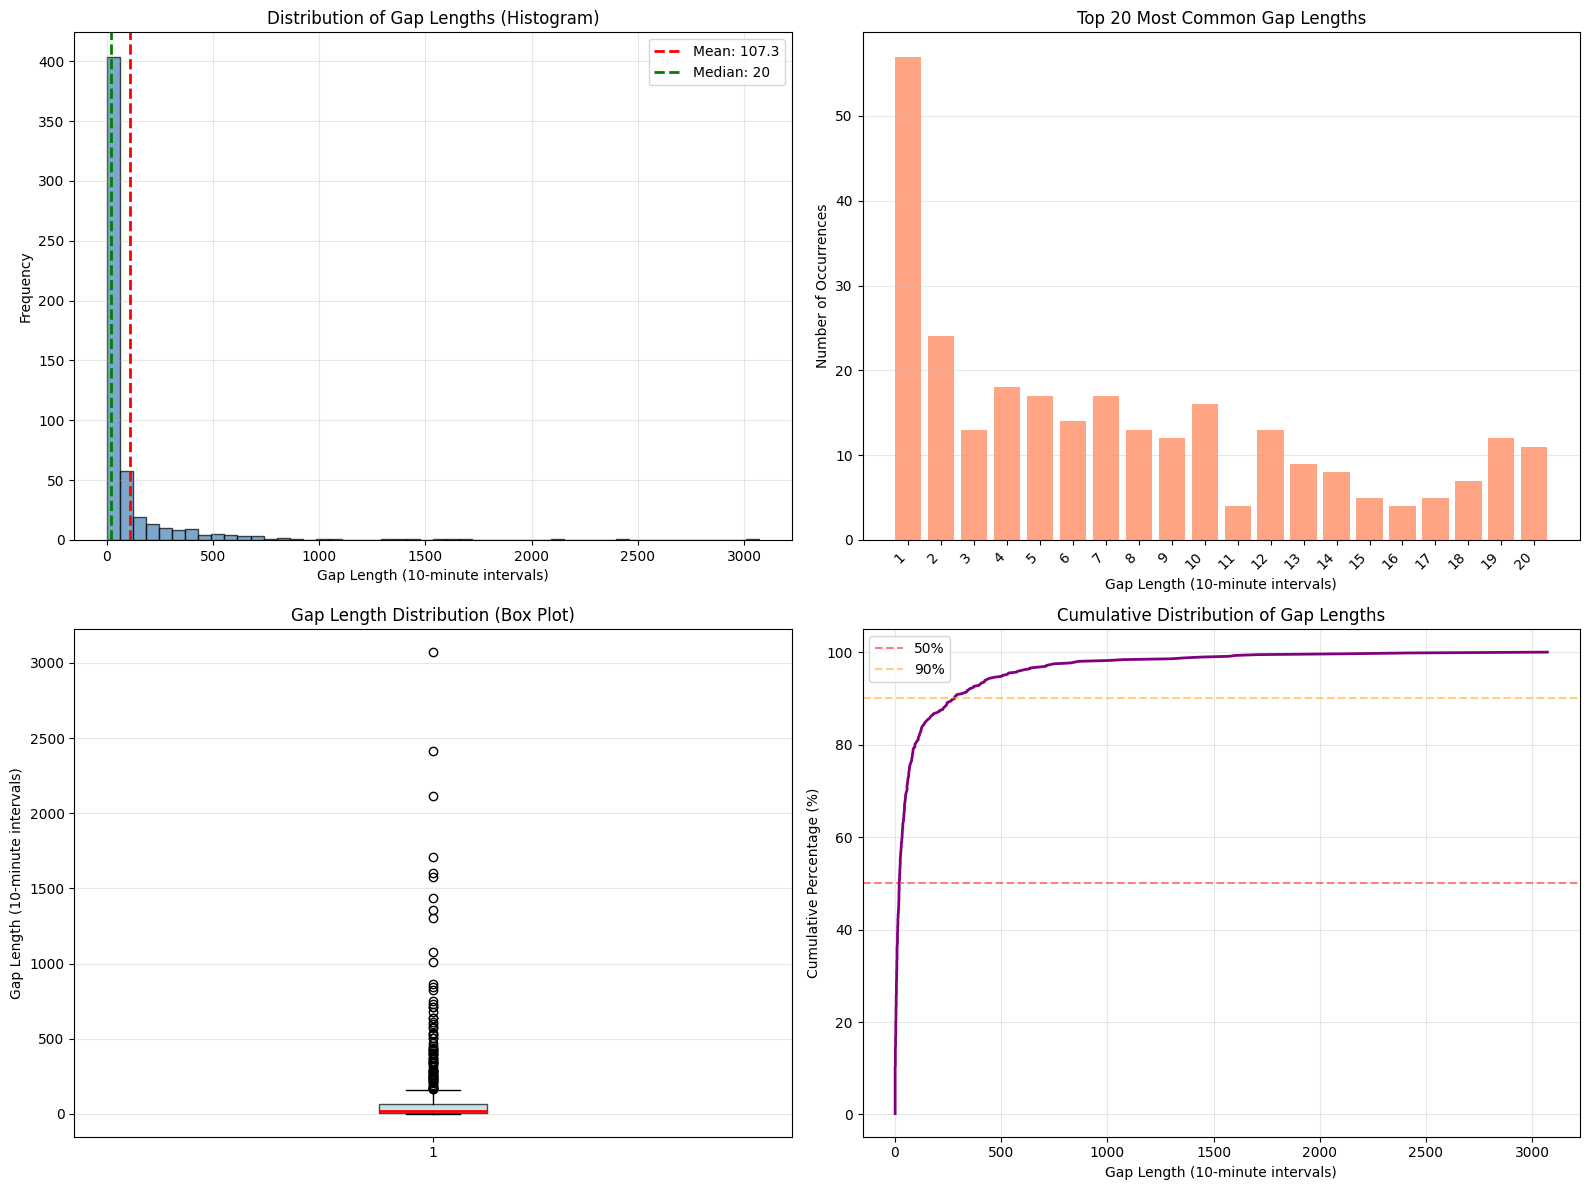

In [54]:
# Visualizations of gap length distribution
if len(all_gaps_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    gap_lengths = all_gaps_df['length'].values
    gap_length_counts = all_gaps_df['length'].value_counts().sort_index()
    
    # Plot 1: Histogram of gap lengths
    axes[0, 0].hist(gap_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Gap Length (10-minute intervals)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of Gap Lengths (Histogram)')
    axes[0, 0].axvline(x=gap_lengths.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {gap_lengths.mean():.1f}')
    axes[0, 0].axvline(x=np.median(gap_lengths), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(gap_lengths):.0f}')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Plot 2: Bar chart of top 20 most common gap lengths
    top_20 = gap_length_counts.head(20)
    axes[0, 1].bar(range(len(top_20)), top_20.values, color='coral', alpha=0.7)
    axes[0, 1].set_xticks(range(len(top_20)))
    axes[0, 1].set_xticklabels([f"{int(x)}" for x in top_20.index], rotation=45, ha='right')
    axes[0, 1].set_xlabel('Gap Length (10-minute intervals)')
    axes[0, 1].set_ylabel('Number of Occurrences')
    axes[0, 1].set_title('Top 20 Most Common Gap Lengths')
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # Plot 3: Box plot
    axes[1, 0].boxplot(gap_lengths, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', alpha=0.7),
                       medianprops=dict(color='red', linewidth=2))
    axes[1, 0].set_ylabel('Gap Length (10-minute intervals)')
    axes[1, 0].set_title('Gap Length Distribution (Box Plot)')
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    # Plot 4: Cumulative distribution
    sorted_lengths = np.sort(gap_lengths)
    cumulative = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths) * 100
    axes[1, 1].plot(sorted_lengths, cumulative, color='purple', linewidth=2)
    axes[1, 1].set_xlabel('Gap Length (10-minute intervals)')
    axes[1, 1].set_ylabel('Cumulative Percentage (%)')
    axes[1, 1].set_title('Cumulative Distribution of Gap Lengths')
    axes[1, 1].grid(alpha=0.3)
    axes[1, 1].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50%')
    axes[1, 1].axhline(y=90, color='orange', linestyle='--', alpha=0.5, label='90%')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("No gaps to visualize!")


### Per-Station Gap Statistics


In [55]:
# Display per-station gap statistics
print("="*100)
print(" PER-STATION GAP STATISTICS")
print("="*100)
print()

# Format the dataframe for better display
station_gap_display = station_gap_df.copy()
station_gap_display = station_gap_display.round(2)
station_gap_display = station_gap_display.sort_values('num_gaps', ascending=False)

print(station_gap_display.to_string(index=False))

# Summary statistics
print("\n" + "="*100)
print(" SUMMARY ACROSS STATIONS")
print("="*100)

stations_with_gaps = station_gap_df[station_gap_df['num_gaps'] > 0]
if len(stations_with_gaps) > 0:
    print(f"\nStations with gaps: {len(stations_with_gaps)} out of {len(station_gap_df)}")
    print(f"\nAverage number of gaps per station (with gaps): {stations_with_gaps['num_gaps'].mean():.1f}")
    print(f"Average mean gap length across stations: {stations_with_gaps['mean_gap_length'].mean():.2f} intervals")
    print(f"Average median gap length across stations: {stations_with_gaps['median_gap_length'].mean():.2f} intervals")
    
    print(f"\nStation with most gaps: {station_gap_display.iloc[0]['station_id']} ({station_gap_display.iloc[0]['num_gaps']:.0f} gaps)")
    print(f"Station with longest average gap: {stations_with_gaps.loc[stations_with_gaps['mean_gap_length'].idxmax(), 'station_id']} " +
          f"({stations_with_gaps['mean_gap_length'].max():.1f} intervals)")
    print(f"Station with longest single gap: {stations_with_gaps.loc[stations_with_gaps['max_gap_length'].idxmax(), 'station_id']} " +
          f"({stations_with_gaps['max_gap_length'].max():.0f} intervals = {stations_with_gaps['max_gap_length'].max() * 10 / 60:.1f} hours)")
else:
    print("\nNo stations have gaps!")


 PER-STATION GAP STATISTICS

 station_id  num_gaps  total_missing_intervals  mean_gap_length  median_gap_length  min_gap_length  max_gap_length
       5142       131                     1707            13.03                2.0               1             420
       5109        71                     5484            77.24               42.0               2             846
         96        33                     3878           117.52               51.0               8             505
        303        33                     3824           115.88               40.0               7            1074
       5546        30                     2611            87.03               40.0               5             610
       7351        29                     3082           106.28               67.0               5             532
       1605        24                     2604           108.50               25.5               6            1708
        427        21                     1353     

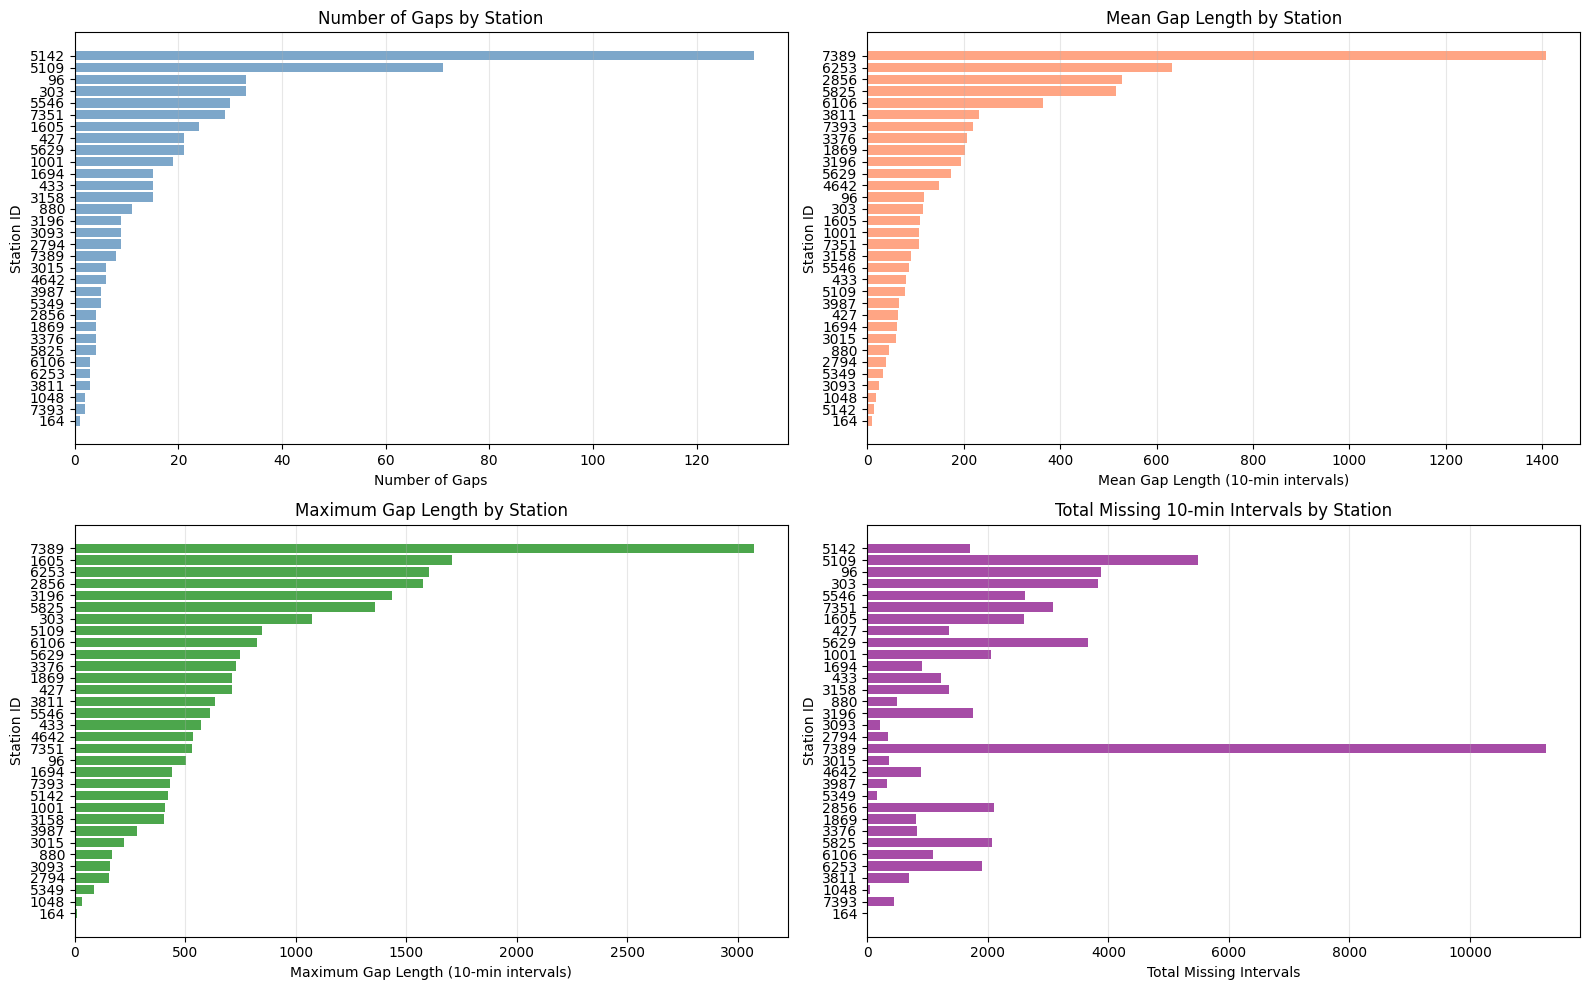

In [56]:
# Visualization of per-station gap statistics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Sort for better visualization
station_gap_sorted = station_gap_df.sort_values('num_gaps', ascending=True)

# Plot 1: Number of gaps per station
axes[0, 0].barh(range(len(station_gap_sorted)), station_gap_sorted['num_gaps'], color='steelblue', alpha=0.7)
axes[0, 0].set_yticks(range(len(station_gap_sorted)))
axes[0, 0].set_yticklabels(station_gap_sorted['station_id'])
axes[0, 0].set_xlabel('Number of Gaps')
axes[0, 0].set_ylabel('Station ID')
axes[0, 0].set_title('Number of Gaps by Station')
axes[0, 0].grid(axis='x', alpha=0.3)

# Plot 2: Mean gap length per station
station_gap_sorted_mean = station_gap_df[station_gap_df['mean_gap_length'] > 0].sort_values('mean_gap_length', ascending=True)
axes[0, 1].barh(range(len(station_gap_sorted_mean)), station_gap_sorted_mean['mean_gap_length'], color='coral', alpha=0.7)
axes[0, 1].set_yticks(range(len(station_gap_sorted_mean)))
axes[0, 1].set_yticklabels(station_gap_sorted_mean['station_id'])
axes[0, 1].set_xlabel('Mean Gap Length (10-min intervals)')
axes[0, 1].set_ylabel('Station ID')
axes[0, 1].set_title('Mean Gap Length by Station')
axes[0, 1].grid(axis='x', alpha=0.3)

# Plot 3: Max gap length per station
station_gap_sorted_max = station_gap_df[station_gap_df['max_gap_length'] > 0].sort_values('max_gap_length', ascending=True)
axes[1, 0].barh(range(len(station_gap_sorted_max)), station_gap_sorted_max['max_gap_length'], color='green', alpha=0.7)
axes[1, 0].set_yticks(range(len(station_gap_sorted_max)))
axes[1, 0].set_yticklabels(station_gap_sorted_max['station_id'])
axes[1, 0].set_xlabel('Maximum Gap Length (10-min intervals)')
axes[1, 0].set_ylabel('Station ID')
axes[1, 0].set_title('Maximum Gap Length by Station')
axes[1, 0].grid(axis='x', alpha=0.3)

# Plot 4: Total missing intervals per station
axes[1, 1].barh(range(len(station_gap_sorted)), station_gap_sorted['total_missing_intervals'], color='purple', alpha=0.7)
axes[1, 1].set_yticks(range(len(station_gap_sorted)))
axes[1, 1].set_yticklabels(station_gap_sorted['station_id'])
axes[1, 1].set_xlabel('Total Missing Intervals')
axes[1, 1].set_ylabel('Station ID')
axes[1, 1].set_title('Total Missing 10-min Intervals by Station')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


### Gap Length Frequency Table (DataFrame)


In [57]:
# Create a comprehensive frequency table DataFrame
if len(all_gaps_df) > 0:
    gap_length_counts = all_gaps_df['length'].value_counts().sort_index()
    
    frequency_table = pd.DataFrame({
        'gap_length_intervals': gap_length_counts.index,
        'duration_minutes': gap_length_counts.index * 10,
        'duration_hours': (gap_length_counts.index * 10) / 60,
        'occurrences': gap_length_counts.values,
        'percentage': (gap_length_counts.values / len(all_gaps_df) * 100)
    })
    
    frequency_table = frequency_table.round(2)
    
    print("Gap Length Frequency Table (all entries):")
    print("\nFirst 30 rows:")
    print(frequency_table.head(30).to_string(index=False))
    
    if len(frequency_table) > 30:
        print(f"\n... {len(frequency_table) - 30} more rows ...")
        print("\nLast 10 rows:")
        print(frequency_table.tail(10).to_string(index=False))
    
    # Store in variable for further analysis
    print(f"\n✓ Frequency table stored in 'frequency_table' variable with {len(frequency_table)} unique gap lengths")
    
    frequency_table
else:
    print("No gaps found!")


Gap Length Frequency Table (all entries):

First 30 rows:
 gap_length_intervals  duration_minutes  duration_hours  occurrences  percentage
                    1                10            0.17           57       10.27
                    2                20            0.33           24        4.32
                    3                30            0.50           13        2.34
                    4                40            0.67           18        3.24
                    5                50            0.83           17        3.06
                    6                60            1.00           14        2.52
                    7                70            1.17           17        3.06
                    8                80            1.33           13        2.34
                    9                90            1.50           12        2.16
                   10               100            1.67           16        2.88
                   11               110            

### Gap Statistics by Year


In [60]:
# Analyze gaps by year
if len(all_gaps_df) > 0:
    # Extract year from gap start date
    all_gaps_df['year'] = pd.to_datetime(all_gaps_df['start']).dt.year
    
    # Group by year and calculate statistics
    yearly_stats = []
    
    for year in sorted(all_gaps_df['year'].unique()):
        year_gaps = all_gaps_df[all_gaps_df['year'] == year]
        gap_lengths = year_gaps['length'].values
        
        yearly_stats.append({
            'year': year,
            'num_gaps': len(year_gaps),
            'total_missing_intervals': gap_lengths.sum(),
            'mean_gap_length': gap_lengths.mean(),
            'median_gap_length': np.median(gap_lengths),
            'min_gap_length': gap_lengths.min(),
            'max_gap_length': gap_lengths.max(),
            'std_gap_length': gap_lengths.std(),
            'short_gaps_<=1h': (gap_lengths <= 6).sum(),
            'medium_gaps_1-24h': ((gap_lengths > 6) & (gap_lengths <= 144)).sum(),
            'long_gaps_>24h': (gap_lengths > 144).sum()
        })
    
    yearly_stats_df = pd.DataFrame(yearly_stats)
    
    print("="*100)
    print(" GAP STATISTICS BY YEAR")
    print("="*100)
    print()
    
    # Display the table
    display_df = yearly_stats_df.copy()
    display_df = display_df.round(2)
    print(display_df.to_string(index=False))
    
    print("\n" + "="*100)
    print(" YEARLY TRENDS")
    print("="*100)
    
    # Calculate year-over-year changes
    print(f"\nTotal years in dataset: {len(yearly_stats_df)}")
    print(f"Year with most gaps: {yearly_stats_df.loc[yearly_stats_df['num_gaps'].idxmax(), 'year']} ({yearly_stats_df['num_gaps'].max():,} gaps)")
    print(f"Year with fewest gaps: {yearly_stats_df.loc[yearly_stats_df['num_gaps'].idxmin(), 'year']} ({yearly_stats_df['num_gaps'].min():,} gaps)")
    print(f"\nYear with longest average gap: {yearly_stats_df.loc[yearly_stats_df['mean_gap_length'].idxmax(), 'year']} ({yearly_stats_df['mean_gap_length'].max():.1f} intervals)")
    print(f"Year with shortest average gap: {yearly_stats_df.loc[yearly_stats_df['mean_gap_length'].idxmin(), 'year']} ({yearly_stats_df['mean_gap_length'].min():.1f} intervals)")
    
    # Show trend direction
    if len(yearly_stats_df) > 1:
        first_year = yearly_stats_df.iloc[0]
        last_year = yearly_stats_df.iloc[-1]
        
        gap_change = last_year['num_gaps'] - first_year['num_gaps']
        gap_change_pct = (gap_change / first_year['num_gaps'] * 100) if first_year['num_gaps'] > 0 else 0
        
        print(f"\n📊 Trend from {first_year['year']} to {last_year['year']}:")
        print(f"  Number of gaps: {first_year['num_gaps']:.0f} → {last_year['num_gaps']:.0f} ({gap_change:+.0f}, {gap_change_pct:+.1f}%)")
        print(f"  Mean gap length: {first_year['mean_gap_length']:.1f} → {last_year['mean_gap_length']:.1f} intervals")
        print(f"  Total missing intervals: {first_year['total_missing_intervals']:.0f} → {last_year['total_missing_intervals']:.0f}")
        
        if gap_change > 0:
            print(f"\n⚠️  Data quality appears to have degraded (more gaps in recent years)")
        elif gap_change < 0:
            print(f"\n✓ Data quality appears to have improved (fewer gaps in recent years)")
        else:
            print(f"\n→ Data quality remained stable")
    
    # Store for later use
    print("\n✓ Yearly statistics stored in 'yearly_stats_df' variable")
else:
    print("No gaps to analyze by year!")


 GAP STATISTICS BY YEAR

 year  num_gaps  total_missing_intervals  mean_gap_length  median_gap_length  min_gap_length  max_gap_length  std_gap_length  short_gaps_<=1h  medium_gaps_1-24h  long_gaps_>24h
 2020        46                     9339           203.02               36.0               2            2115          433.24                2                 33              11
 2021       159                     8521            53.59                3.0               1            1357          173.92              108                 37              14
 2022        80                     7777            97.21               26.5               1            1601          216.15               16                 54              10
 2023       108                    12948           119.89               30.0               1            3072          349.67                8                 85              15
 2024        71                     7546           106.28               34.0              

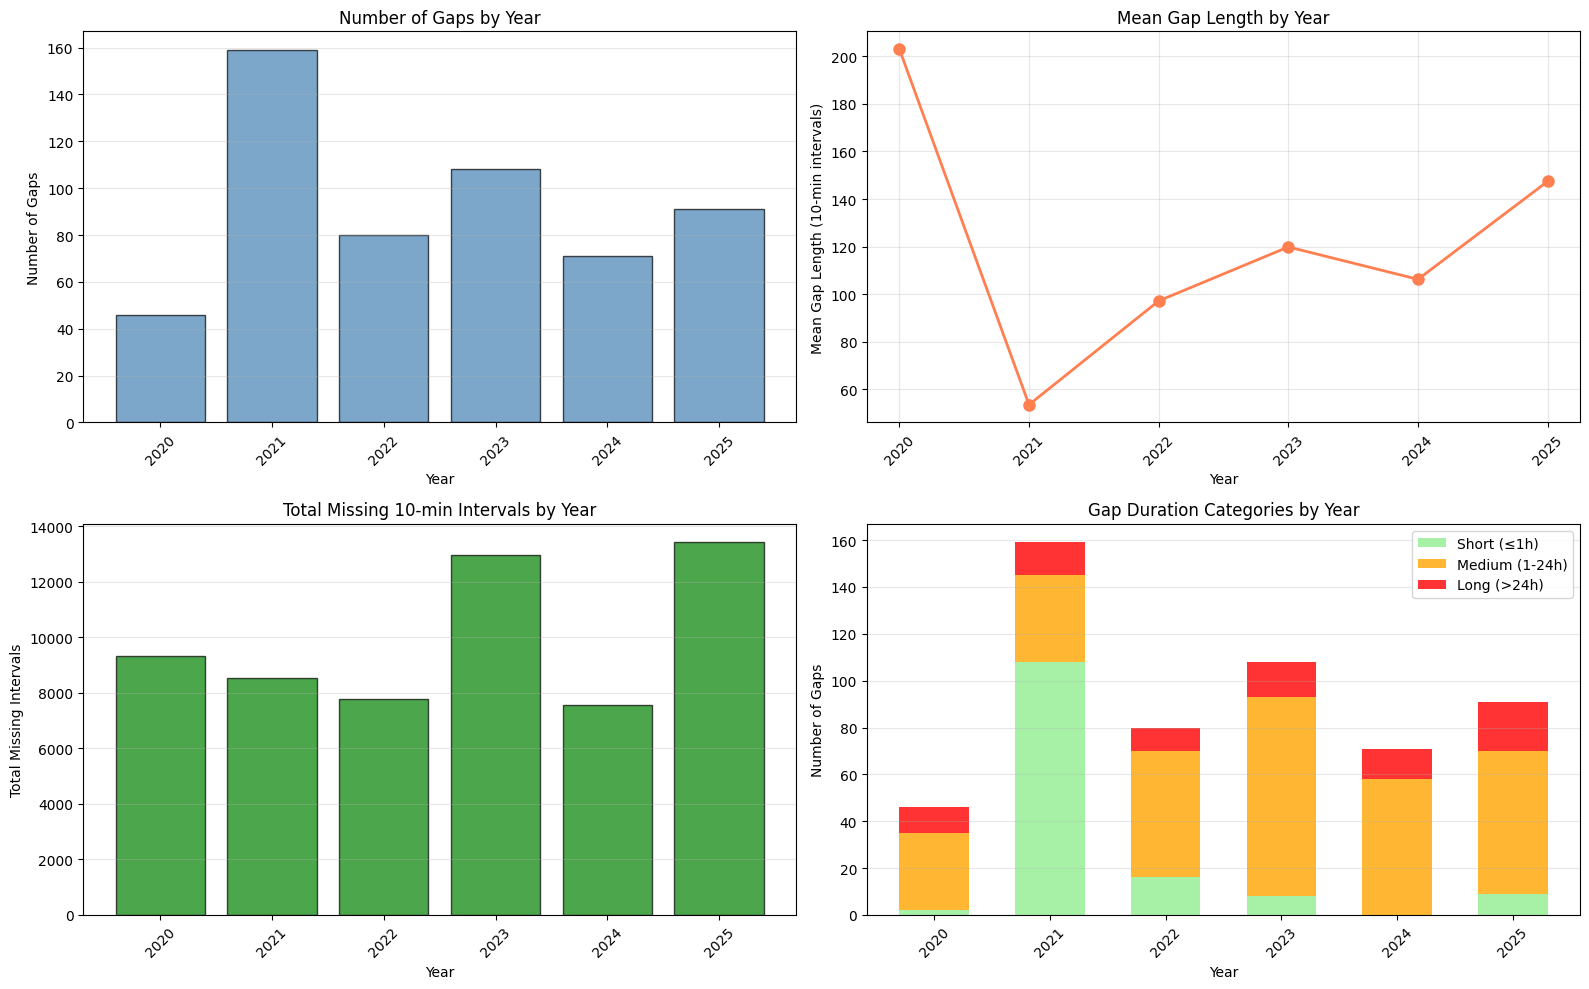

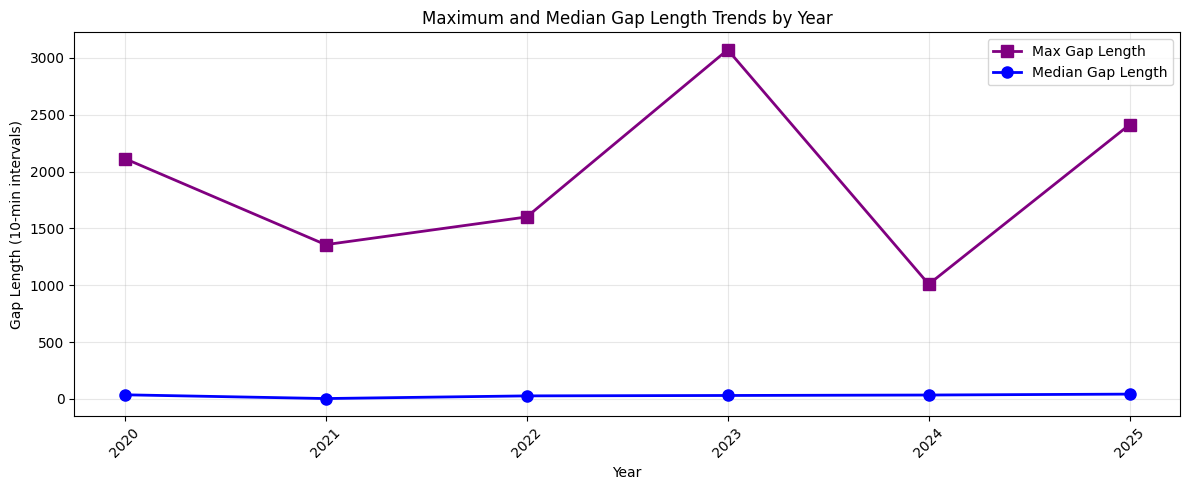

In [61]:
# Visualize yearly trends
if len(all_gaps_df) > 0 and len(yearly_stats_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    years = yearly_stats_df['year'].values
    
    # Plot 1: Number of gaps per year
    axes[0, 0].bar(years, yearly_stats_df['num_gaps'], color='steelblue', alpha=0.7, edgecolor='black')
    axes[0, 0].set_xlabel('Year')
    axes[0, 0].set_ylabel('Number of Gaps')
    axes[0, 0].set_title('Number of Gaps by Year')
    axes[0, 0].grid(axis='y', alpha=0.3)
    axes[0, 0].set_xticks(years)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # Plot 2: Mean gap length per year
    axes[0, 1].plot(years, yearly_stats_df['mean_gap_length'], marker='o', color='coral', linewidth=2, markersize=8)
    axes[0, 1].set_xlabel('Year')
    axes[0, 1].set_ylabel('Mean Gap Length (10-min intervals)')
    axes[0, 1].set_title('Mean Gap Length by Year')
    axes[0, 1].grid(alpha=0.3)
    axes[0, 1].set_xticks(years)
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # Plot 3: Total missing intervals per year
    axes[1, 0].bar(years, yearly_stats_df['total_missing_intervals'], color='green', alpha=0.7, edgecolor='black')
    axes[1, 0].set_xlabel('Year')
    axes[1, 0].set_ylabel('Total Missing Intervals')
    axes[1, 0].set_title('Total Missing 10-min Intervals by Year')
    axes[1, 0].grid(axis='y', alpha=0.3)
    axes[1, 0].set_xticks(years)
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Plot 4: Stacked bar chart of gap categories
    width = 0.6
    axes[1, 1].bar(years, yearly_stats_df['short_gaps_<=1h'], width, label='Short (≤1h)', color='lightgreen', alpha=0.8)
    axes[1, 1].bar(years, yearly_stats_df['medium_gaps_1-24h'], width, 
                   bottom=yearly_stats_df['short_gaps_<=1h'], 
                   label='Medium (1-24h)', color='orange', alpha=0.8)
    axes[1, 1].bar(years, yearly_stats_df['long_gaps_>24h'], width,
                   bottom=yearly_stats_df['short_gaps_<=1h'] + yearly_stats_df['medium_gaps_1-24h'],
                   label='Long (>24h)', color='red', alpha=0.8)
    axes[1, 1].set_xlabel('Year')
    axes[1, 1].set_ylabel('Number of Gaps')
    axes[1, 1].set_title('Gap Duration Categories by Year')
    axes[1, 1].legend()
    axes[1, 1].grid(axis='y', alpha=0.3)
    axes[1, 1].set_xticks(years)
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Additional line plot for max gap length trend
    plt.figure(figsize=(12, 5))
    plt.plot(years, yearly_stats_df['max_gap_length'], marker='s', color='purple', linewidth=2, markersize=8, label='Max Gap Length')
    plt.plot(years, yearly_stats_df['median_gap_length'], marker='o', color='blue', linewidth=2, markersize=8, label='Median Gap Length')
    plt.xlabel('Year')
    plt.ylabel('Gap Length (10-min intervals)')
    plt.title('Maximum and Median Gap Length Trends by Year')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xticks(years, rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No data to visualize!")


In [ ]:
# Display yearly statistics DataFrame
if len(all_gaps_df) > 0 and len(yearly_stats_df) > 0:
    print("Yearly Gap Statistics DataFrame:")
    yearly_stats_df
else:
    print("No yearly statistics available!")


## Feature Quality Analysis - Missing Values (-999)

Analyzing missing values (encoded as -999) in all measurement features


In [62]:
# Identify all numeric features (exclude station_id and date columns)
print("Analyzing features for missing values encoded as -999...\n")

# Get all numeric columns
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove station_id if present
numeric_features = [col for col in numeric_features if col not in ['station_id']]

print(f"Found {len(numeric_features)} numeric features to analyze:")
print(f"{numeric_features}\n")

# Analyze -999 values for each feature
feature_quality = []

for feature in numeric_features:
    total_records = len(df)
    missing_count = (df[feature] == -999).sum()
    missing_percentage = (missing_count / total_records) * 100
    valid_count = total_records - missing_count
    valid_percentage = (valid_count / total_records) * 100
    
    # Get some statistics on valid values
    valid_data = df[df[feature] != -999][feature]
    
    feature_quality.append({
        'feature': feature,
        'total_records': total_records,
        'missing_count': missing_count,
        'missing_%': missing_percentage,
        'valid_count': valid_count,
        'valid_%': valid_percentage,
        'valid_mean': valid_data.mean() if len(valid_data) > 0 else np.nan,
        'valid_std': valid_data.std() if len(valid_data) > 0 else np.nan,
        'valid_min': valid_data.min() if len(valid_data) > 0 else np.nan,
        'valid_max': valid_data.max() if len(valid_data) > 0 else np.nan
    })

feature_quality_df = pd.DataFrame(feature_quality)

print("✓ Analysis complete!")


Analyzing features for missing values encoded as -999...

Found 12 numeric features to analyze:
['air_pressure', 'air_temperature_2m', 'air_temperature_5cm', 'average_wind_direction', 'average_wind_speed', 'dew_point_temperature', 'id', 'precipitation_duration', 'precipitation_indicator', 'quality_level', 'relative_humidity', 'sum_precipitation_height']

✓ Analysis complete!


### Overall Feature Quality Summary


In [63]:
# Display overall feature quality summary
print("="*100)
print(" FEATURE QUALITY SUMMARY - MISSING VALUES (-999)")
print("="*100)
print()

# Sort by missing percentage (descending) to show worst features first
feature_quality_sorted = feature_quality_df.sort_values('missing_%', ascending=False)

print("Features ranked by data quality (worst to best):\n")
print(f"{'Feature':<30} {'Total Records':<15} {'Missing (-999)':<15} {'Missing %':<12} {'Valid %':<12}")
print("-" * 100)

for _, row in feature_quality_sorted.iterrows():
    print(f"{row['feature']:<30} {row['total_records']:<15,} {row['missing_count']:<15,} {row['missing_%']:>10.2f}% {row['valid_%']:>10.2f}%")

print("\n" + "="*100)
print(" SUMMARY STATISTICS")
print("="*100)

features_with_missing = feature_quality_df[feature_quality_df['missing_count'] > 0]
features_complete = feature_quality_df[feature_quality_df['missing_count'] == 0]

print(f"\nTotal features analyzed: {len(feature_quality_df)}")
print(f"Features with missing values (-999): {len(features_with_missing)}")
print(f"Features with complete data: {len(features_complete)}")

if len(features_with_missing) > 0:
    print(f"\n📊 Missing Value Statistics:")
    print(f"  Average missing percentage: {features_with_missing['missing_%'].mean():.2f}%")
    print(f"  Median missing percentage: {features_with_missing['missing_%'].median():.2f}%")
    print(f"  Highest missing percentage: {features_with_missing['missing_%'].max():.2f}% ({features_with_missing.loc[features_with_missing['missing_%'].idxmax(), 'feature']})")
    print(f"  Lowest missing percentage: {features_with_missing['missing_%'].min():.2f}% ({features_with_missing.loc[features_with_missing['missing_%'].idxmin(), 'feature']})")
    
    # Show features with high quality (< 1% missing)
    high_quality = feature_quality_df[feature_quality_df['missing_%'] < 1.0]
    print(f"\n✓ High quality features (< 1% missing): {len(high_quality)}")
    if len(high_quality) > 0:
        print(f"  {', '.join(high_quality['feature'].tolist())}")
    
    # Show features with low quality (> 10% missing)
    low_quality = feature_quality_df[feature_quality_df['missing_%'] > 10.0]
    print(f"\n⚠️  Low quality features (> 10% missing): {len(low_quality)}")
    if len(low_quality) > 0:
        print(f"  {', '.join(low_quality['feature'].tolist())}")
else:
    print("\n✓ All features have complete data (no -999 values found)!")


 FEATURE QUALITY SUMMARY - MISSING VALUES (-999)

Features ranked by data quality (worst to best):

Feature                        Total Records   Missing (-999)  Missing %    Valid %     
----------------------------------------------------------------------------------------------------
precipitation_duration         9,620,463       1,901,570            19.77%      80.23%
precipitation_indicator        9,620,463       1,901,570            19.77%      80.23%
air_pressure                   9,620,463       1,893,802            19.69%      80.31%
sum_precipitation_height       9,620,463       713,752               7.42%      92.58%
air_temperature_5cm            9,620,463       705,890               7.34%      92.66%
dew_point_temperature          9,620,463       612,250               6.36%      93.64%
relative_humidity              9,620,463       610,837               6.35%      93.65%
air_temperature_2m             9,620,463       607,416               6.31%      93.69%
average_wind_d

### Feature Quality Visualizations


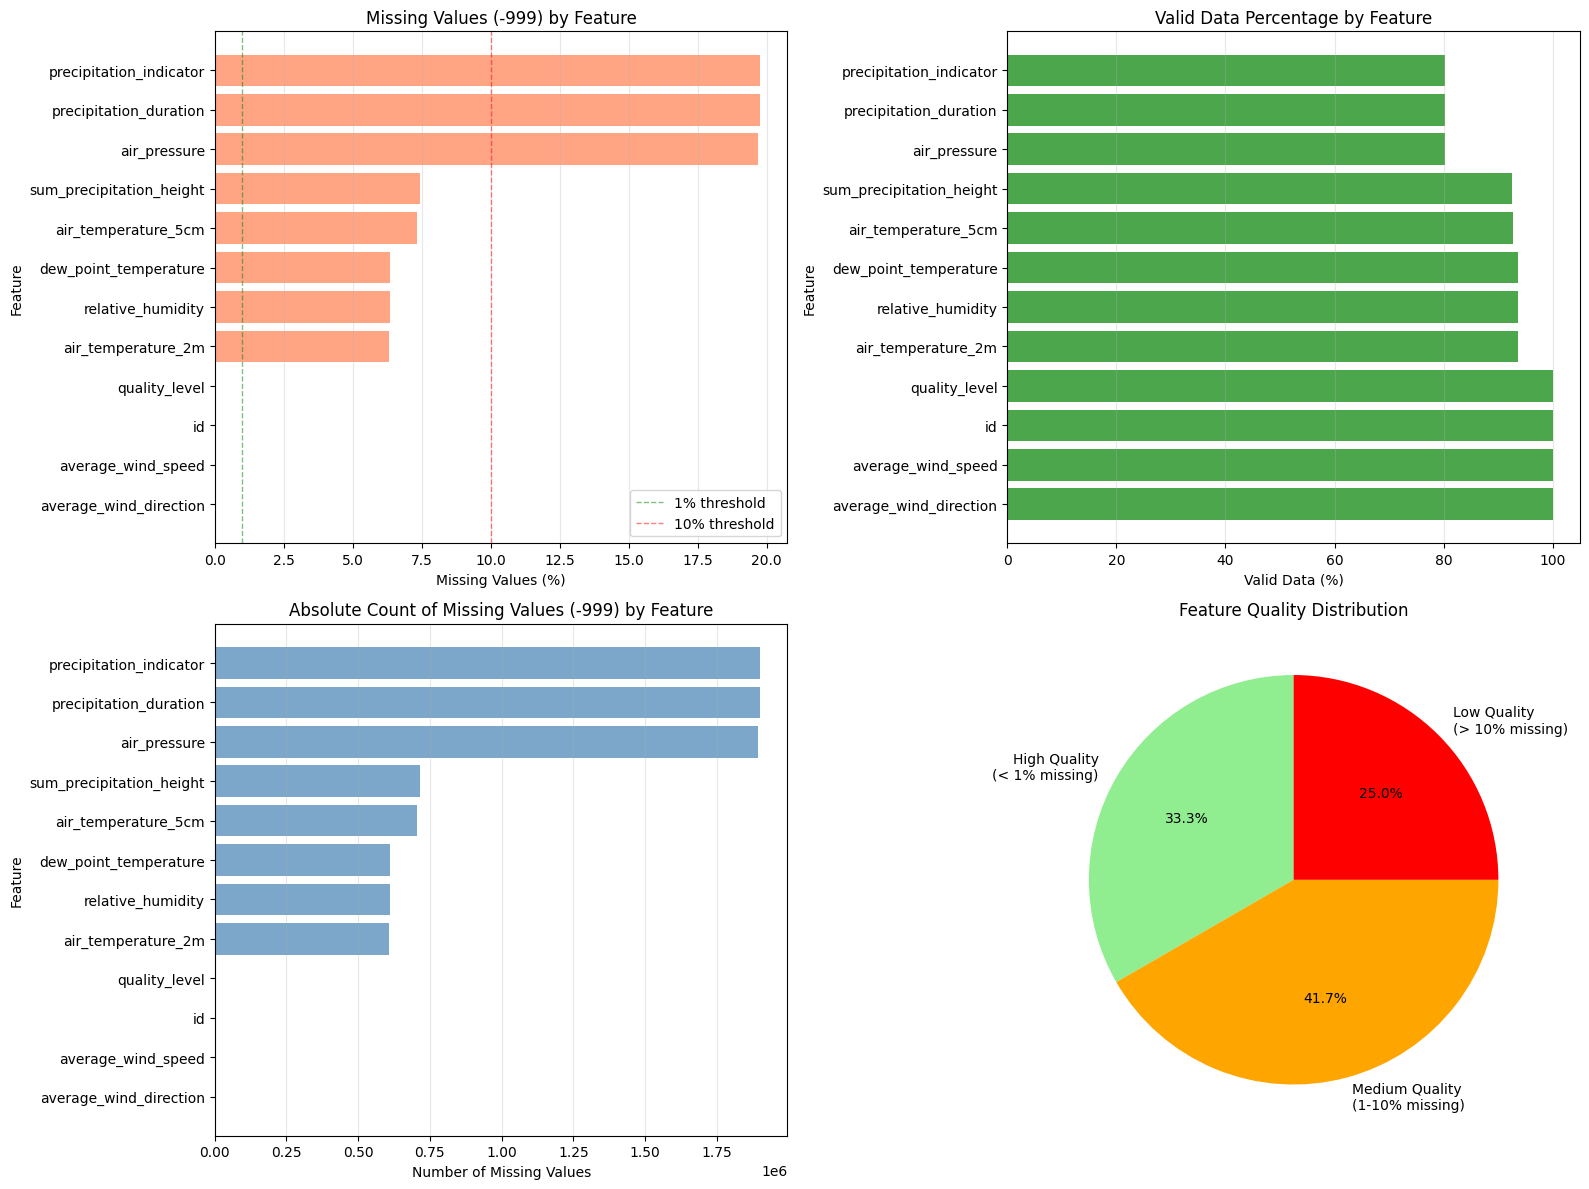

In [64]:
# Visualize feature quality
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Sort by missing percentage for better visualization
feature_sorted = feature_quality_df.sort_values('missing_%', ascending=True)

# Plot 1: Bar chart of missing percentages
axes[0, 0].barh(range(len(feature_sorted)), feature_sorted['missing_%'], color='coral', alpha=0.7)
axes[0, 0].set_yticks(range(len(feature_sorted)))
axes[0, 0].set_yticklabels(feature_sorted['feature'])
axes[0, 0].set_xlabel('Missing Values (%)')
axes[0, 0].set_ylabel('Feature')
axes[0, 0].set_title('Missing Values (-999) by Feature')
axes[0, 0].grid(axis='x', alpha=0.3)
axes[0, 0].axvline(x=1, color='green', linestyle='--', linewidth=1, alpha=0.5, label='1% threshold')
axes[0, 0].axvline(x=10, color='red', linestyle='--', linewidth=1, alpha=0.5, label='10% threshold')
axes[0, 0].legend()

# Plot 2: Bar chart of valid data percentages
axes[0, 1].barh(range(len(feature_sorted)), feature_sorted['valid_%'], color='green', alpha=0.7)
axes[0, 1].set_yticks(range(len(feature_sorted)))
axes[0, 1].set_yticklabels(feature_sorted['feature'])
axes[0, 1].set_xlabel('Valid Data (%)')
axes[0, 1].set_ylabel('Feature')
axes[0, 1].set_title('Valid Data Percentage by Feature')
axes[0, 1].grid(axis='x', alpha=0.3)
axes[0, 1].set_xlim([0, 105])

# Plot 3: Absolute count of missing values
feature_sorted_count = feature_quality_df.sort_values('missing_count', ascending=True)
axes[1, 0].barh(range(len(feature_sorted_count)), feature_sorted_count['missing_count'], 
                color='steelblue', alpha=0.7)
axes[1, 0].set_yticks(range(len(feature_sorted_count)))
axes[1, 0].set_yticklabels(feature_sorted_count['feature'])
axes[1, 0].set_xlabel('Number of Missing Values')
axes[1, 0].set_ylabel('Feature')
axes[1, 0].set_title('Absolute Count of Missing Values (-999) by Feature')
axes[1, 0].grid(axis='x', alpha=0.3)

# Plot 4: Pie chart showing data quality categories
high_quality_count = (feature_quality_df['missing_%'] < 1.0).sum()
medium_quality_count = ((feature_quality_df['missing_%'] >= 1.0) & (feature_quality_df['missing_%'] <= 10.0)).sum()
low_quality_count = (feature_quality_df['missing_%'] > 10.0).sum()

categories = ['High Quality\n(< 1% missing)', 'Medium Quality\n(1-10% missing)', 'Low Quality\n(> 10% missing)']
counts = [high_quality_count, medium_quality_count, low_quality_count]
colors_pie = ['lightgreen', 'orange', 'red']

axes[1, 1].pie(counts, labels=categories, autopct='%1.1f%%', colors=colors_pie, startangle=90)
axes[1, 1].set_title('Feature Quality Distribution')

plt.tight_layout()
plt.show()


### Per-Station Feature Quality Analysis


In [65]:
# Analyze missing values per station per feature
print("Analyzing missing values per station for each feature...")

station_feature_quality = []

for station_id in sorted(df['station_id'].unique()):
    station_df = df[df['station_id'] == station_id]
    station_total = len(station_df)
    
    station_data = {'station_id': station_id, 'total_records': station_total}
    
    for feature in numeric_features:
        missing_count = (station_df[feature] == -999).sum()
        missing_pct = (missing_count / station_total * 100) if station_total > 0 else 0
        station_data[f'{feature}_missing_count'] = missing_count
        station_data[f'{feature}_missing_%'] = missing_pct
    
    station_feature_quality.append(station_data)

station_feature_quality_df = pd.DataFrame(station_feature_quality)

print(f"✓ Analysis complete for {len(station_feature_quality_df)} stations and {len(numeric_features)} features")


Analyzing missing values per station for each feature...
✓ Analysis complete for 32 stations and 12 features


In [66]:
# Display per-station summary for each feature
print("="*120)
print(" PER-STATION MISSING VALUE ANALYSIS")
print("="*120)
print("\nFor each feature, showing stations with highest missing value percentages:\n")

for feature in numeric_features:
    missing_col = f'{feature}_missing_%'
    
    # Get top 5 stations with most missing values for this feature
    top_missing = station_feature_quality_df.nlargest(5, missing_col)
    
    # Calculate overall missing percentage for this feature
    overall_missing = feature_quality_df[feature_quality_df['feature'] == feature]['missing_%'].values[0]
    
    print(f"\n{'='*120}")
    print(f"Feature: {feature}")
    print(f"Overall missing: {overall_missing:.2f}%")
    print(f"{'='*120}")
    
    if top_missing[missing_col].max() > 0:
        print(f"{'Station ID':<15} {'Total Records':<15} {'Missing Count':<15} {'Missing %':<15}")
        print("-" * 120)
        for _, row in top_missing.iterrows():
            if row[missing_col] > 0:
                print(f"{row['station_id']:<15} {row['total_records']:<15,} {row[f'{feature}_missing_count']:<15,} {row[missing_col]:>10.2f}%")
    else:
        print("  ✓ No missing values in any station for this feature")

print("\n" + "="*120)


 PER-STATION MISSING VALUE ANALYSIS

For each feature, showing stations with highest missing value percentages:


Feature: air_pressure
Overall missing: 19.69%
Station ID      Total Records   Missing Count   Missing %      
------------------------------------------------------------------------------------------------------------------------
2856.0          300,959.0       300,959.0           100.00%
3376.0          302,240.0       302,240.0           100.00%
5825.0          301,003.0       301,003.0           100.00%
6106.0          301,979.0       301,979.0           100.00%
6253.0          301,171.0       301,171.0           100.00%

Feature: air_temperature_2m
Overall missing: 6.31%
Station ID      Total Records   Missing Count   Missing %      
------------------------------------------------------------------------------------------------------------------------
6106.0          301,979.0       301,979.0           100.00%
6253.0          301,171.0       301,171.0           100.00

### Heatmap: Missing Values by Station and Feature


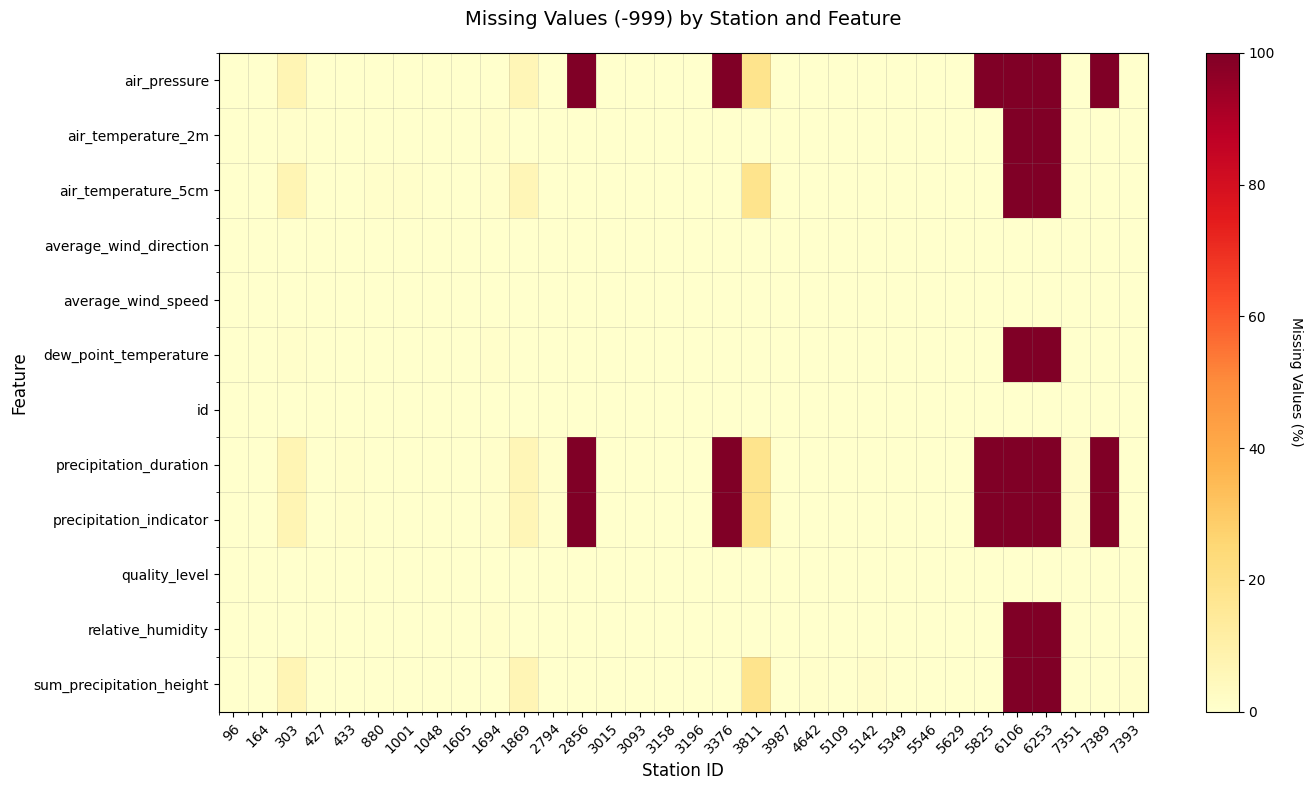


💡 Interpretation:
  • Darker red = more missing values
  • Lighter yellow/white = fewer missing values
  • Use this to identify problematic station-feature combinations


In [67]:
# Create heatmap of missing values
import matplotlib.pyplot as plt

# Prepare data for heatmap (missing percentages)
heatmap_data = []
for feature in numeric_features:
    missing_col = f'{feature}_missing_%'
    heatmap_data.append(station_feature_quality_df[missing_col].values)

heatmap_array = np.array(heatmap_data)

# Create heatmap
fig, ax = plt.subplots(figsize=(14, max(8, len(numeric_features) * 0.5)))

im = ax.imshow(heatmap_array, cmap='YlOrRd', aspect='auto')

# Set ticks and labels
ax.set_xticks(np.arange(len(station_feature_quality_df)))
ax.set_yticks(np.arange(len(numeric_features)))
ax.set_xticklabels(station_feature_quality_df['station_id'])
ax.set_yticklabels(numeric_features)

# Rotate the tick labels for better readability
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Missing Values (%)', rotation=270, labelpad=20)

# Add title and labels
ax.set_title('Missing Values (-999) by Station and Feature', fontsize=14, pad=20)
ax.set_xlabel('Station ID', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)

# Add grid
ax.set_xticks(np.arange(len(station_feature_quality_df))-.5, minor=True)
ax.set_yticks(np.arange(len(numeric_features))-.5, minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 Interpretation:")
print(f"  • Darker red = more missing values")
print(f"  • Lighter yellow/white = fewer missing values")
print(f"  • Use this to identify problematic station-feature combinations")


### Detailed Feature Quality DataFrame


In [68]:
# Display detailed feature quality dataframe
print("Detailed Feature Quality DataFrame with Statistics on Valid Values:\n")

# Format for display
display_df = feature_quality_df.copy()
display_df = display_df.round(2)
display_df = display_df.sort_values('missing_%', ascending=False)

print(display_df.to_string(index=False))

print("\n✓ Feature quality data stored in 'feature_quality_df' variable")
print("✓ Per-station feature quality data stored in 'station_feature_quality_df' variable")

# Show the dataframe
display_df


Detailed Feature Quality DataFrame with Statistics on Valid Values:

                 feature  total_records  missing_count  missing_%  valid_count  valid_%  valid_mean  valid_std  valid_min   valid_max
  precipitation_duration        9620463        1901570      19.77      7718893    80.23        0.98       2.80        0.0       10.00
 precipitation_indicator        9620463        1901570      19.77      7718893    80.23        0.13       0.33        0.0        1.00
            air_pressure        9620463        1893802      19.69      7726661    80.31     1006.46      11.30      953.8     1046.70
sum_precipitation_height        9620463         713752       7.42      8906711    92.58        0.01       0.11        0.0       19.43
     air_temperature_5cm        9620463         705890       7.34      8914573    92.66       10.65       9.06      -25.5       45.70
   dew_point_temperature        9620463         612250       6.36      9008213    93.64        6.05       6.22      -22.6      

,feature,total_records,missing_count,missing_%,valid_count,valid_%,valid_mean,valid_std,valid_min,valid_max
7,precipitation_duration,9620463,1901570,19.77,7718893,80.23,0.98,2.80,0.0,10.00
8,precipitation_indicator,9620463,1901570,19.77,7718893,80.23,0.13,0.33,0.0,1.00
0,air_pressure,9620463,1893802,19.69,7726661,80.31,1006.46,11.30,953.8,1046.70
11,sum_precipitation_height,9620463,713752,7.42,8906711,92.58,0.01,0.11,0.0,19.43
2,air_temperature_5cm,9620463,705890,7.34,8914573,92.66,10.65,9.06,-25.5,45.70
5,dew_point_temperature,9620463,612250,6.36,9008213,93.64,6.05,6.22,-22.6,23.60
10,relative_humidity,9620463,610837,6.35,9009626,93.65,75.54,18.29,10.9,100.00
1,air_temperature_2m,9620463,607416,6.31,9013047,93.69,10.82,7.93,-20.2,39.10
3,average_wind_direction,9620463,0,0.00,9620463,100.00,200.66,90.21,0.0,360.00
4,average_wind_speed,9620463,0,0.00,9620463,100.00,3.32,1.95,0.0,22.40


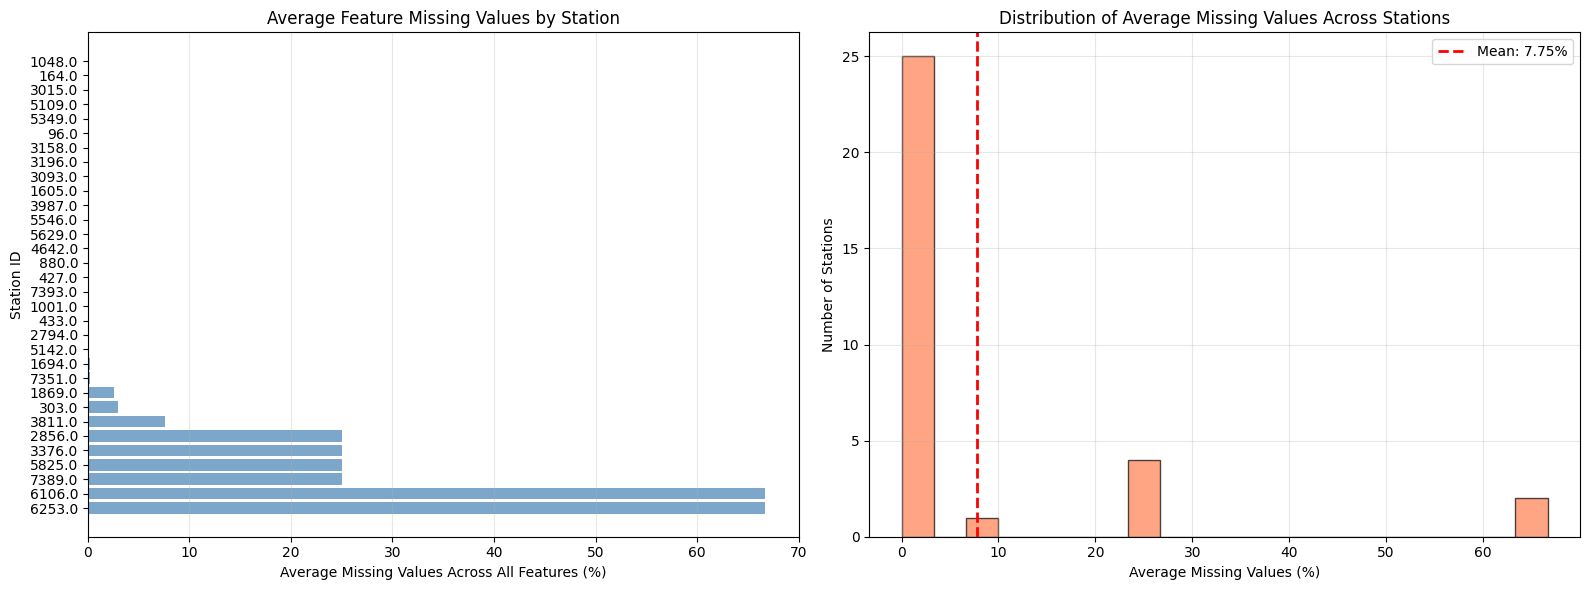


📊 Station-Level Summary:
  Station with highest avg missing values: 6253.0 (66.67%)
  Station with lowest avg missing values: 1048.0 (0.01%)
  Average across all stations: 7.75%


In [69]:
# Additional visualization: station-level summary
# Calculate average missing percentage per station across all features
station_avg_missing = []

for _, row in station_feature_quality_df.iterrows():
    missing_cols = [col for col in station_feature_quality_df.columns if col.endswith('_missing_%')]
    avg_missing = np.mean([row[col] for col in missing_cols])
    station_avg_missing.append({
        'station_id': row['station_id'],
        'avg_missing_%': avg_missing
    })

station_avg_missing_df = pd.DataFrame(station_avg_missing)
station_avg_missing_df = station_avg_missing_df.sort_values('avg_missing_%', ascending=False)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Average missing percentage per station
axes[0].barh(range(len(station_avg_missing_df)), station_avg_missing_df['avg_missing_%'], 
             color='steelblue', alpha=0.7)
axes[0].set_yticks(range(len(station_avg_missing_df)))
axes[0].set_yticklabels(station_avg_missing_df['station_id'])
axes[0].set_xlabel('Average Missing Values Across All Features (%)')
axes[0].set_ylabel('Station ID')
axes[0].set_title('Average Feature Missing Values by Station')
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Distribution of average missing percentages
axes[1].hist(station_avg_missing_df['avg_missing_%'], bins=20, color='coral', 
             edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Average Missing Values (%)')
axes[1].set_ylabel('Number of Stations')
axes[1].set_title('Distribution of Average Missing Values Across Stations')
axes[1].axvline(x=station_avg_missing_df['avg_missing_%'].mean(), color='red', 
                linestyle='--', linewidth=2, label=f"Mean: {station_avg_missing_df['avg_missing_%'].mean():.2f}%")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Station-Level Summary:")
print(f"  Station with highest avg missing values: {station_avg_missing_df.iloc[0]['station_id']} ({station_avg_missing_df.iloc[0]['avg_missing_%']:.2f}%)")
print(f"  Station with lowest avg missing values: {station_avg_missing_df.iloc[-1]['station_id']} ({station_avg_missing_df.iloc[-1]['avg_missing_%']:.2f}%)")
print(f"  Average across all stations: {station_avg_missing_df['avg_missing_%'].mean():.2f}%")


In [70]:
frequency_table

,gap_length_intervals,duration_minutes,duration_hours,occurrences,percentage
0,1,10,0.17,57,10.27
1,2,20,0.33,24,4.32
2,3,30,0.50,13,2.34
3,4,40,0.67,18,3.24
4,5,50,0.83,17,3.06
...,...,...,...,...,...
180,1601,16010,266.83,1,0.18
181,1708,17080,284.67,1,0.18
182,2115,21150,352.50,1,0.18
183,2414,24140,402.33,1,0.18
